In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

读取数据

In [2]:
df = pd.read_csv('results_36000.csv')
# 将 M1, M2, M3 视为 Reject 状态进行合并
mapping = {
    'M1': 'Over_Step',
    'M2': 'Over_Step',
    'M3': 'Over_Step'
}
df['final_state'] = df['final_state'].replace(mapping)

# 打印清洗后的状态分布，确保 M1/M2/M3 已消失
print("清洗后的决策状态分布：")
print(df['final_state'].value_counts())
print("-" * 30)

清洗后的决策状态分布：
Accept_M2          16641
Reject             10773
Accept_M3           5472
Accept_M1           3105
Over_Step              7
Review_Required        2
Name: final_state, dtype: int64
------------------------------


初始模型与最终选择模型之间的相关度

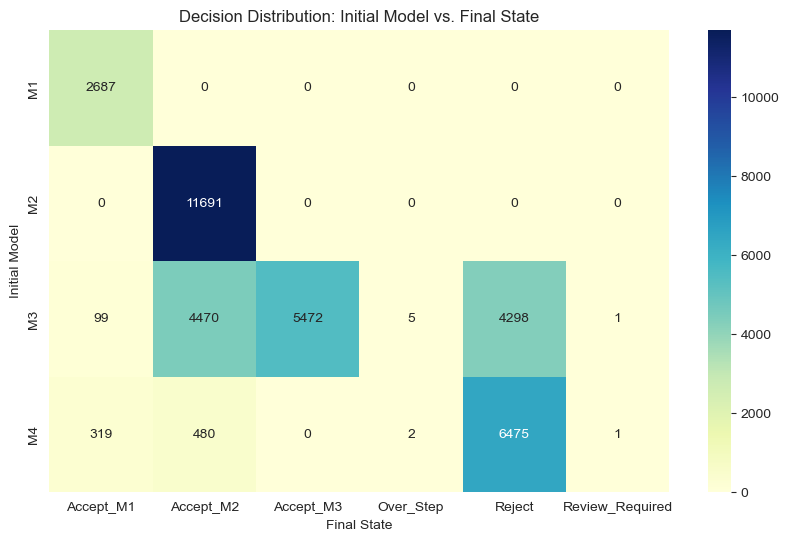

In [3]:
plt.figure(figsize=(10, 6))
decision_matrix = pd.crosstab(df['initial_identified_model'], df['final_state'])
sns.heatmap(decision_matrix, annot=True, cmap="YlGnBu", fmt='d')
plt.title("Decision Distribution: Initial Model vs. Final State")
plt.xlabel("Final State")
plt.ylabel("Initial Model")
plt.show()

初始模型和奖励之间的关系

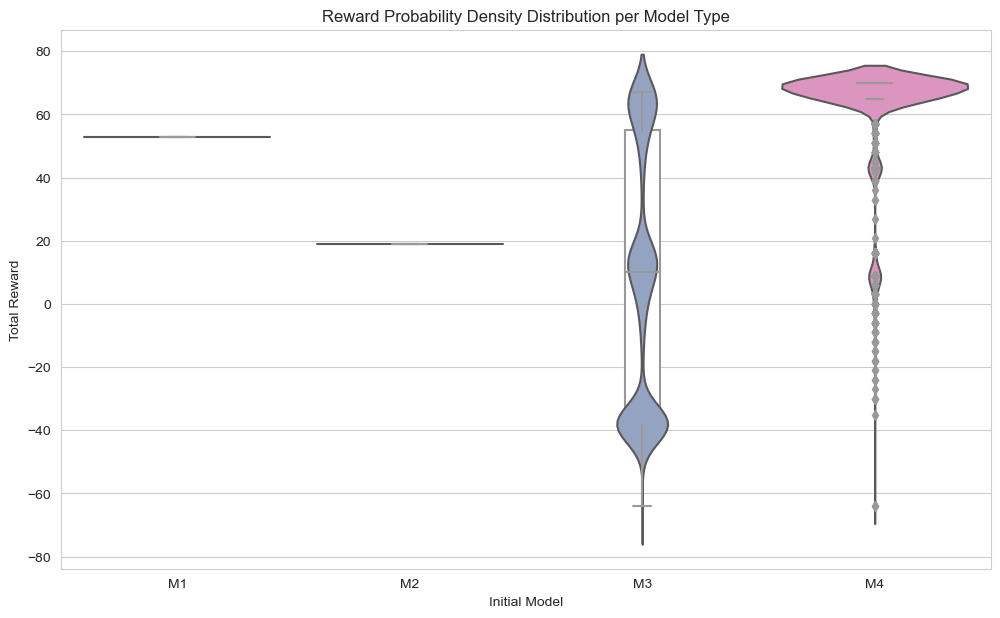

In [4]:
plt.figure(figsize=(12, 7))
sns.violinplot(x='initial_identified_model', y='total_reward', data=df,
               palette="Set2", order=['M1', 'M2', 'M3', 'M4'], inner=None, alpha=0.6)
sns.boxplot(x='initial_identified_model', y='total_reward', data=df,
            width=0.15, color="white", order=['M1', 'M2', 'M3', 'M4'])
plt.title("Reward Probability Density Distribution per Model Type")
plt.xlabel("Initial Model")
plt.ylabel("Total Reward")
plt.show()

对输入输出进行编码

In [5]:
input_features = ['d', 'b', 'r', 'c']
# Encoding inputs for correlation calculation
df_encoded_inputs = df[input_features].copy()
le = LabelEncoder()
for col in input_features:
    df_encoded_inputs[col] = le.fit_transform(df_encoded_inputs[col].astype(str))

# Encoding final_state into actual outcomes
df_decisions = pd.get_dummies(df['final_state'], prefix='Result')

# Combine encoded inputs, numeric metrics, and expanded decisions
analysis_df = pd.concat([df_encoded_inputs, df_decisions, df[['total_steps', 'total_reward']]], axis=1)

输入与终端决策之间的关系

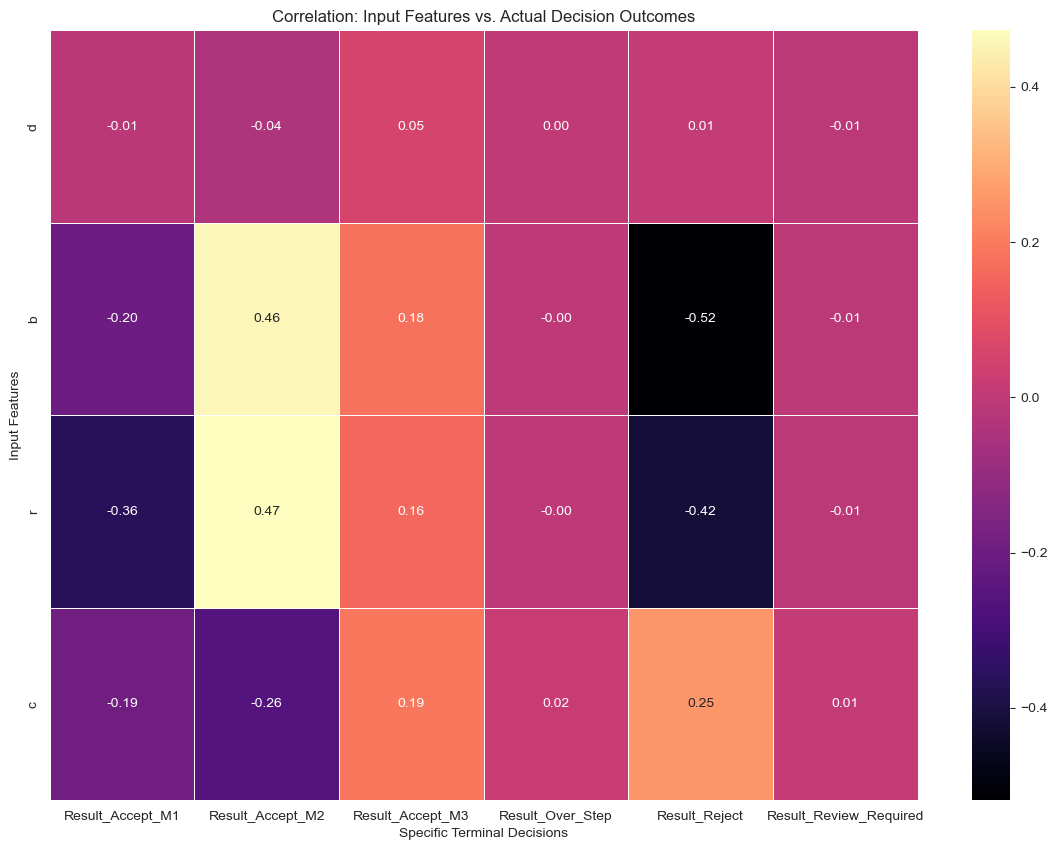

In [6]:
plt.figure(figsize=(14, 10))
# Calculate correlation and slice it to show Features vs. Specific Decisions
corr_matrix = analysis_df.corr()
sub_corr = corr_matrix.loc[input_features, df_decisions.columns]

sns.heatmap(sub_corr, annot=True, cmap="magma", fmt=".2f", linewidths=0.5)
plt.title("Correlation: Input Features vs. Actual Decision Outcomes")
plt.xlabel("Specific Terminal Decisions")
plt.ylabel("Input Features")
plt.show()

奖励与动作步数之间的关系

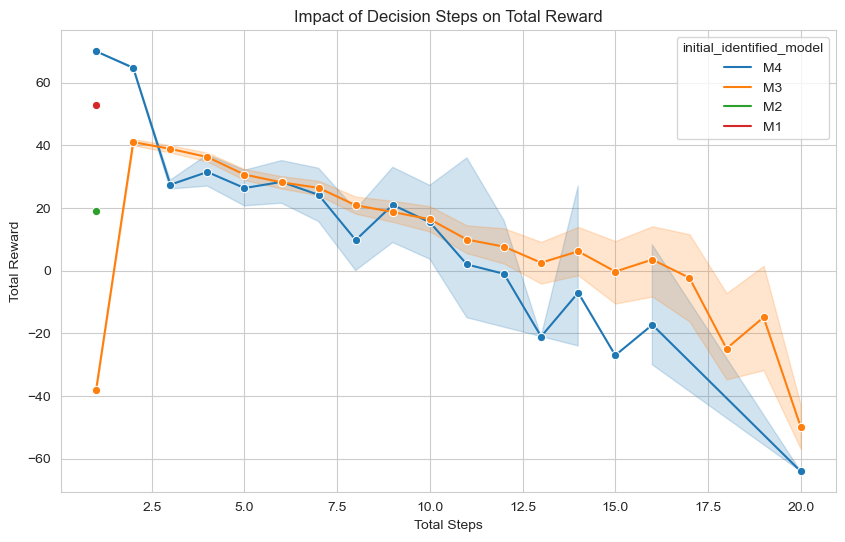

In [7]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='total_steps', y='total_reward', hue='initial_identified_model', data=df, marker='o')
plt.title("Impact of Decision Steps on Total Reward")
plt.xlabel("Total Steps")
plt.ylabel("Total Reward")
plt.show()

那些输入导致Reject

--- d 在 Reject 中的分布 ---
unstructured_text    0.370278
image                0.221016
multimodal           0.187135
structured           0.157152
video                0.064420
Name: d, dtype: float64
--- b 在 Reject 中的分布 ---
categorisation    0.601040
remote_id         0.189919
none              0.111854
verification      0.097187
Name: b, dtype: float64
--- c 在 Reject 中的分布 ---
non_compliant     0.438596
inadequate_SCC    0.223800
EU_only           0.169405
adequacy          0.168198
Name: c, dtype: float64
--- m 在 Reject 中的分布 ---
insufficient    0.785204
suboptimal      0.208299
optimal         0.006498
Name: m, dtype: float64


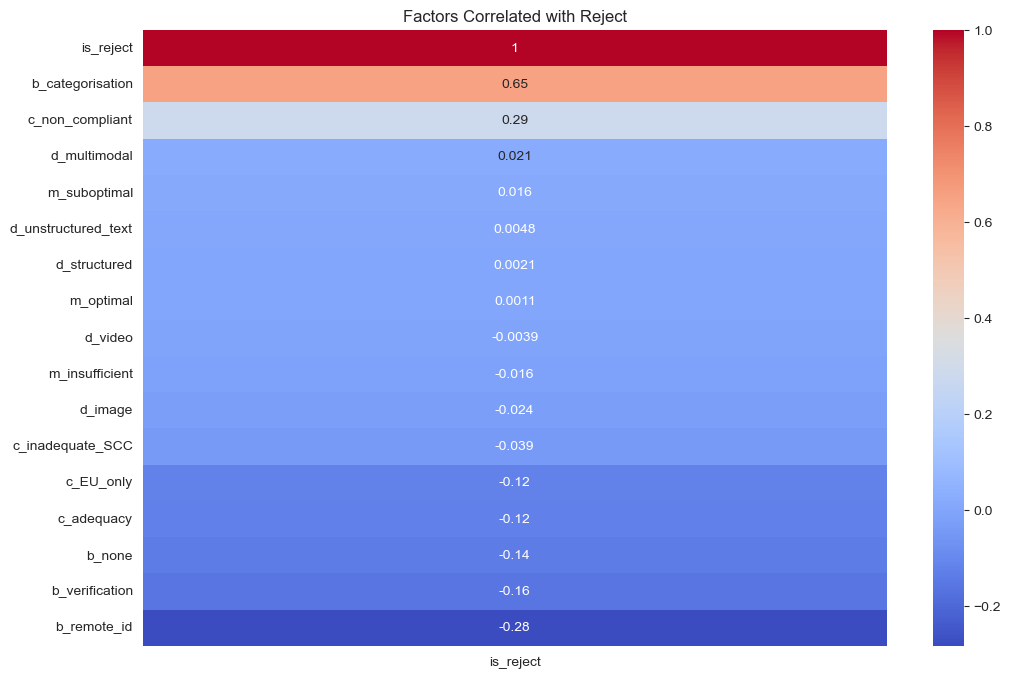

In [8]:
reject_df = df[df['final_state'] == 'Reject']

# 观察类别特征（例如 d, b, c）在 Reject 中的分布
features_to_check = ['d', 'b', 'c', 'm']
for col in features_to_check:
    print(f"--- {col} 在 Reject 中的分布 ---")
    print(reject_df[col].value_counts(normalize=True))

df['is_reject'] = (df['final_state'] == 'Reject').astype(int)
# 对类别变量进行 One-Hot 编码以便计算相关性
df_encoded = pd.get_dummies(df[['d', 'b', 'c', 'm', 'is_reject']])

# 计算相关性并绘图
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr()[['is_reject']].sort_values(by='is_reject', ascending=False),
            annot=True, cmap='coolwarm')
plt.title("Factors Correlated with Reject")
plt.show()

在拒绝的动作中，r和d之间的影响

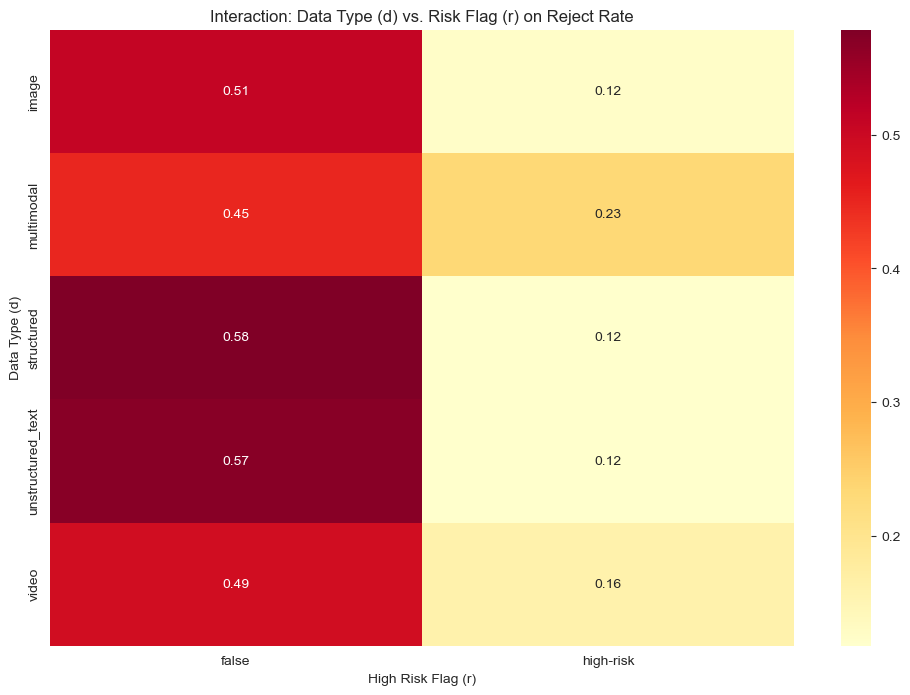

In [9]:
df['is_reject'] = (df['final_state'] == 'Reject').astype(int)
plt.figure(figsize=(12, 8))
interaction_pivot = df.pivot_table(index='d', columns='r', values='is_reject', aggfunc='mean')
sns.heatmap(interaction_pivot, annot=True, cmap="YlOrRd", fmt=".2f")
plt.title("Interaction: Data Type (d) vs. Risk Flag (r) on Reject Rate")
plt.ylabel("Data Type (d)")
plt.xlabel("High Risk Flag (r)")
plt.show()

In [10]:
metrics_list = df['m_metrics'].apply(ast.literal_eval).tolist()
metrics_df = pd.DataFrame(metrics_list, columns=['m_loss', 'm_accuracy', 'm_recall', 'm_precision'])

# 3. 准备主分析表
# 选择基础特征 + 结果特征
base_features = ['d', 'b', 'r', 'c', 'm']
outcomes = ['total_steps', 'total_reward', 'final_state']
df_analysis = pd.concat([df[base_features], metrics_df, df[outcomes]], axis=1)

# 4. 数值化处理
le = LabelEncoder()
for col in ['d', 'b', 'r', 'c', 'm', 'final_state']:
    df_analysis[col] = le.fit_transform(df_analysis[col].astype(str))

# 5. 计算相关性矩阵
corr_matrix = df_analysis.corr()

if 'final_state' in df.columns:
    df_reject = pd.get_dummies(df['final_state'])['Reject']
    reject_corr = \
    pd.concat([df_analysis.drop(columns=['final_state', 'total_reward', 'total_steps']), df_reject], axis=1).corr()[
        'Reject']

    print("-" * 30)
    print("Metrics correlation with 'Reject' decision:")
    print(reject_corr[['m_loss', 'm_accuracy', 'm_recall', 'm_precision']].sort_values(ascending=False))
    print("-" * 30)

------------------------------
Metrics correlation with 'Reject' decision:
m_precision    0.005020
m_accuracy     0.001398
m_recall       0.001236
m_loss        -0.008897
Name: Reject, dtype: float64
------------------------------


处理数据

In [11]:
input_features = ['d', 'b', 'r', 'c', 'm']
df_inputs = df[input_features].copy()
le = LabelEncoder()
for col in input_features:
    df_inputs[col] = le.fit_transform(df_inputs[col].astype(str))

# 将 final_state 展开为“真正的结果” (One-Hot Encoding)
# 这会生成 Decision_Accept_M1, Decision_Reject 等列
df_decisions = pd.get_dummies(df['final_state'], prefix='Decision')

#  合并所有维度进行相关性计算
# 包含：输入基础特征 + 拆解后的指标 + 具体的决策结果 + 总奖励
df_full_analysis = pd.concat([df_inputs, metrics_df, df_decisions, df['total_reward'], df['total_steps']], axis=1)

# 提取相关性矩阵
corr_matrix = df_full_analysis.corr()

# 输入特征 + 性能指标 VS 具体决策结果 ---
# 我们只截取 [输入特征+指标] 作为纵轴，[决策结果] 作为横轴
plt.figure(figsize=(16, 10))

# 纵轴选择：基础特征 + 4个指标
y_axis_labels = input_features + ['m_loss', 'm_accuracy', 'm_recall', 'm_precision']
# 横轴选择：所有 Decision_ 开头的列
x_axis_labels = [col for col in df_decisions.columns]

# 提取子矩阵
sub_corr_matrix = corr_matrix.loc[y_axis_labels, x_axis_labels]

<Figure size 1600x1000 with 0 Axes>

所有输入与终端决策相关度

Text(52.72222222222221, 0.5, 'Input Features & Model Metrics')

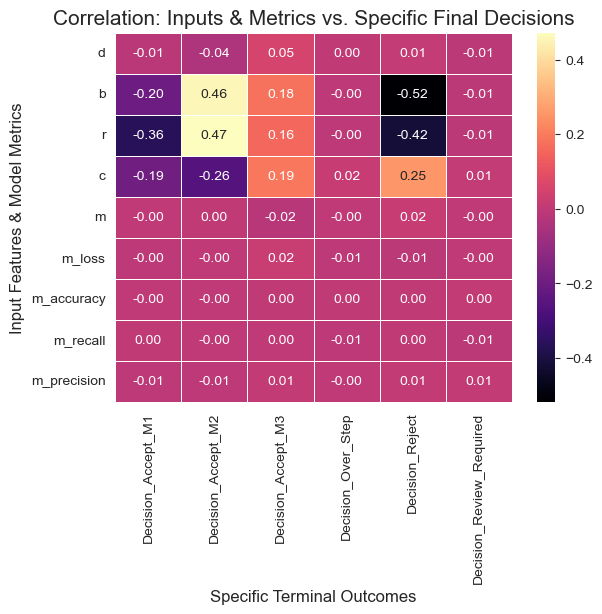

In [12]:
sns.heatmap(sub_corr_matrix, annot=True, cmap="magma", fmt=".2f", linewidths=0.5)
plt.title("Correlation: Inputs & Metrics vs. Specific Final Decisions", fontsize=15)
plt.xlabel("Specific Terminal Outcomes", fontsize=12)
plt.ylabel("Input Features & Model Metrics", fontsize=12)

全部变量相关度

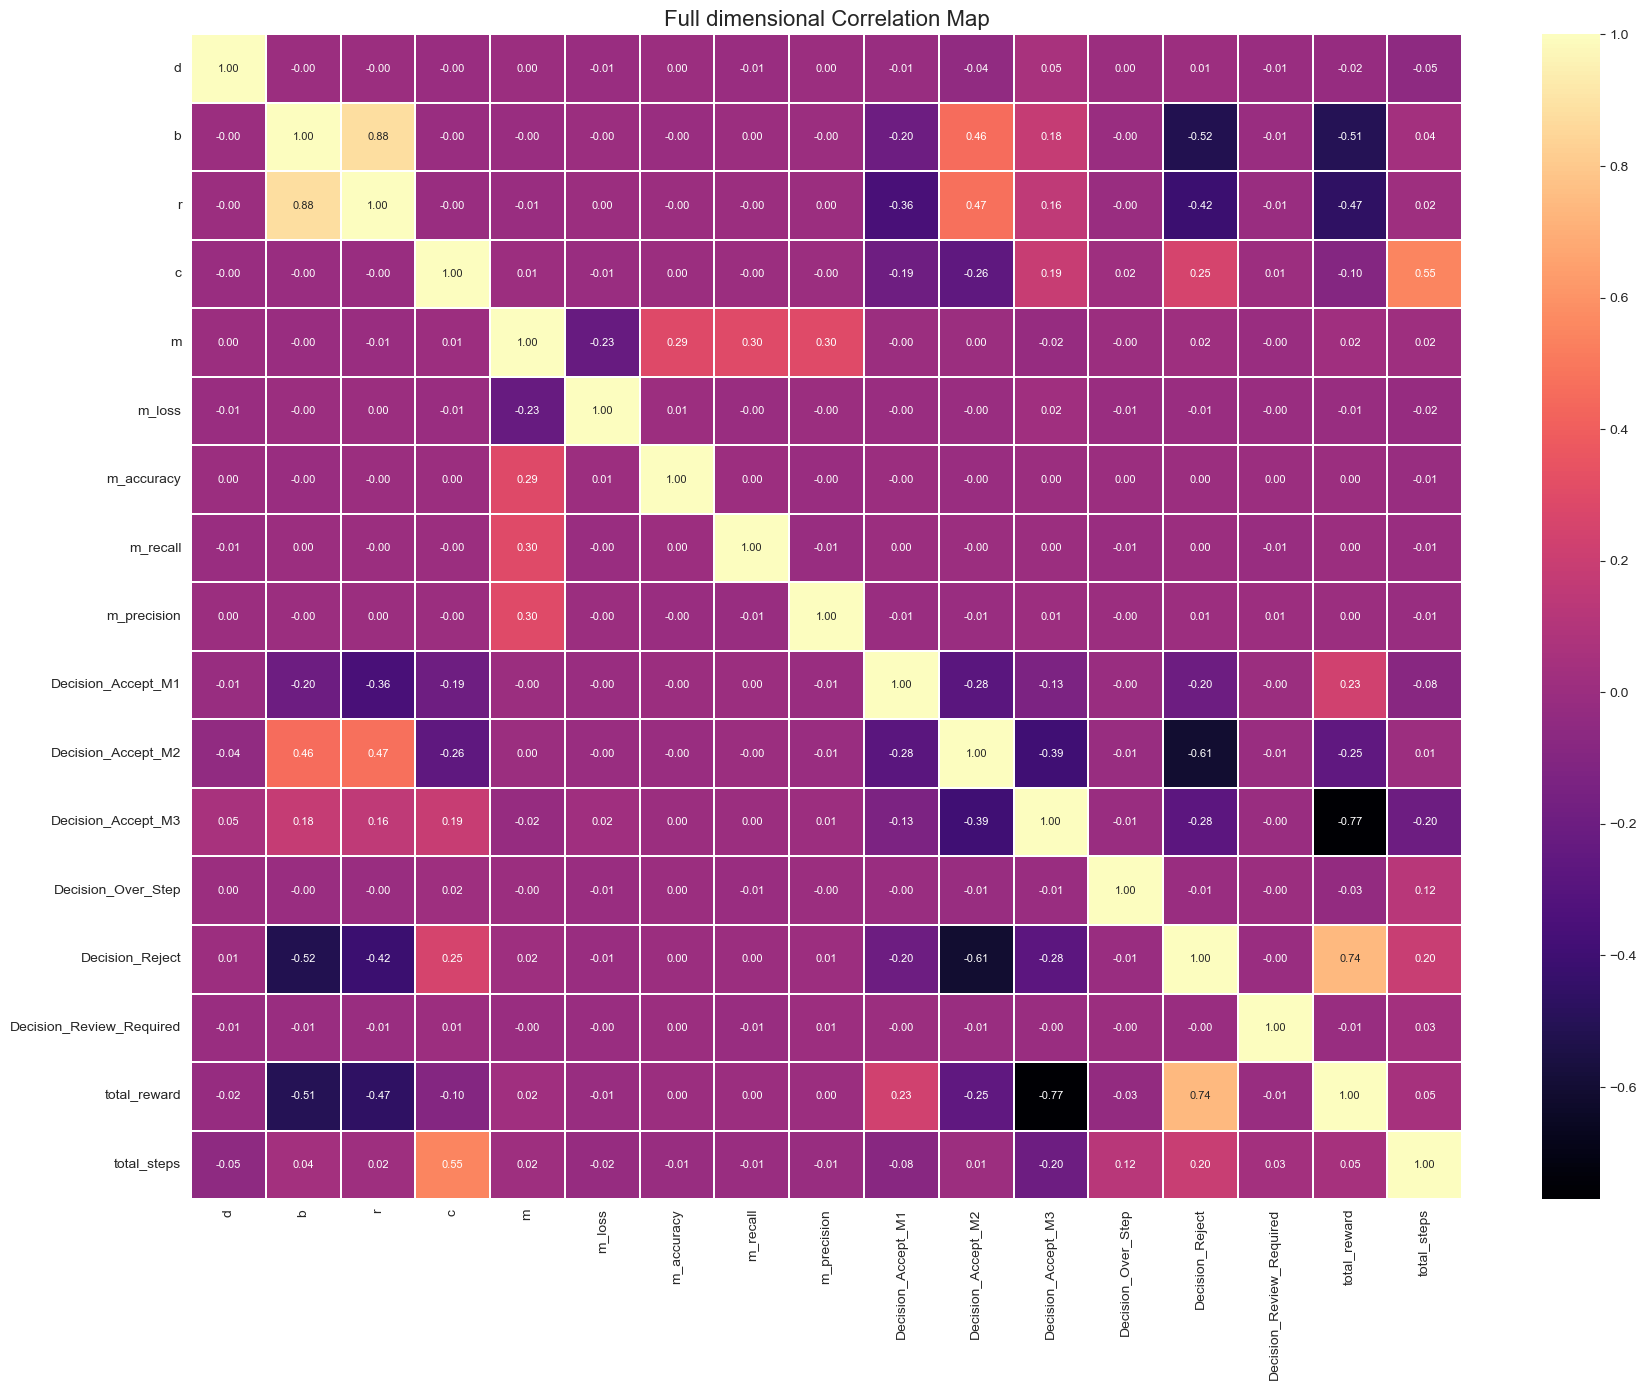

In [13]:
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=True, cmap="magma", fmt=".2f", linewidths=0.3, annot_kws={"size": 8})
plt.title("Full dimensional Correlation Map", fontsize=16)
plt.tight_layout()
plt.show()


In [14]:
print("-" * 30)
print("Decision Outcome Distribution:")
print(df['final_state'].value_counts())
print("-" * 30)

------------------------------
Decision Outcome Distribution:
Accept_M2          16641
Reject             10773
Accept_M3           5472
Accept_M1           3105
Over_Step              7
Review_Required        2
Name: final_state, dtype: int64
------------------------------


d值与终端决策之间的关系

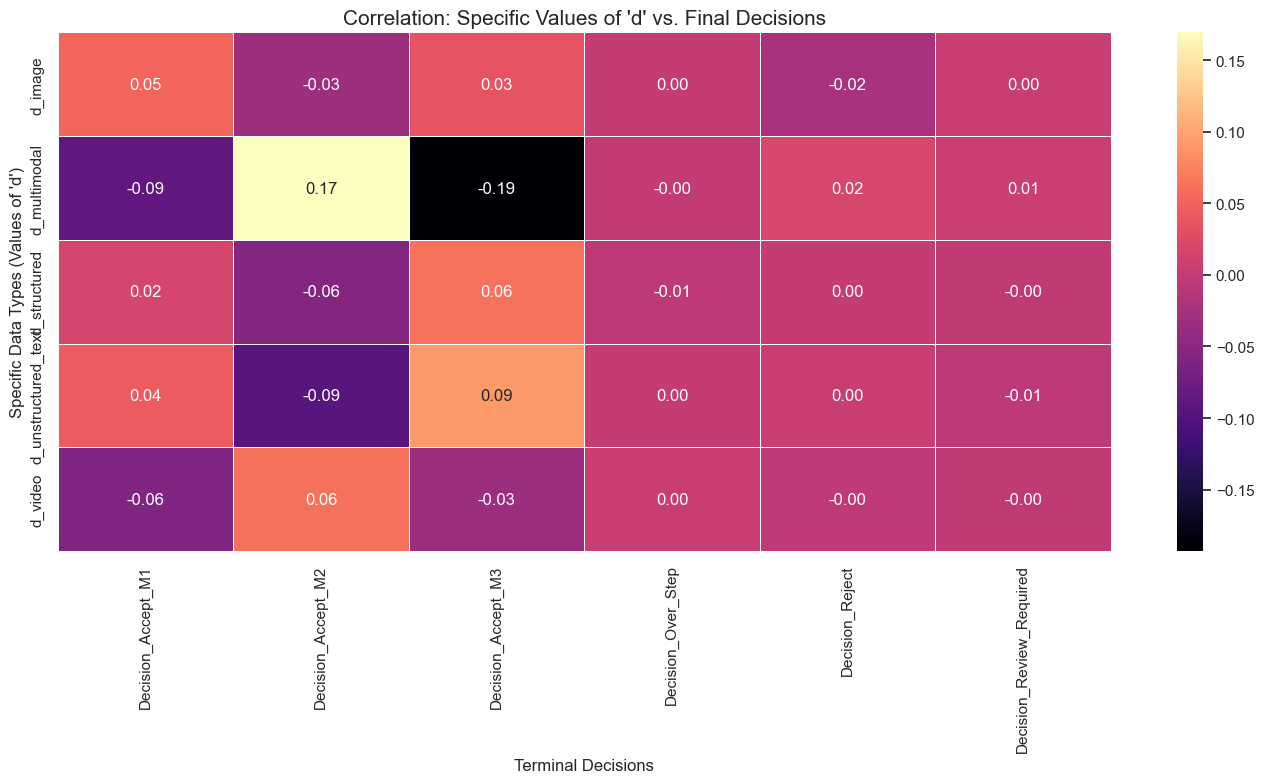

In [15]:
sns.set_theme(style="whitegrid")

#将特征 'd' 展开为具体数值列 (One-Hot)
df_d_values = pd.get_dummies(df['d'], prefix='d')
df_decisions = pd.get_dummies(df['final_state'], prefix='Decision')

# 我们只关注 d 的具体值与最终决策之间的关系
df_d_corr = pd.concat([df_d_values, df_decisions], axis=1)
corr_matrix = df_d_corr.corr()
sub_corr = corr_matrix.loc[df_d_values.columns, df_decisions.columns]


plt.figure(figsize=(14, 8))
sns.heatmap(sub_corr, annot=True, cmap="magma", fmt=".2f", linewidths=0.5)

plt.title("Correlation: Specific Values of 'd' vs. Final Decisions", fontsize=15)
plt.xlabel("Terminal Decisions", fontsize=12)
plt.ylabel("Specific Data Types (Values of 'd')", fontsize=12)
plt.tight_layout()
plt.show()

In [16]:
print("-" * 30)
print("Distribution of Decisions per Data Type (d):")
pivot_table = pd.crosstab(df['d'], df['final_state'], normalize='index') * 100
print(pivot_table.round(2).astype(str) + '%')
print("-" * 30)

------------------------------
Distribution of Decisions per Data Type (d):
final_state       Accept_M1 Accept_M2 Accept_M3 Over_Step  Reject  \
d                                                                   
image                11.21%    43.31%    17.46%     0.02%  27.99%   
multimodal            3.27%    64.56%     0.16%     0.02%  31.98%   
structured            9.71%    39.77%    20.37%      0.0%  30.15%   
unstructured_text    10.19%    40.02%    19.56%     0.02%  30.22%   
video                 2.32%     57.8%    10.58%     0.04%  29.26%   

final_state       Review_Required  
d                                  
image                       0.01%  
multimodal                  0.02%  
structured                   0.0%  
unstructured_text            0.0%  
video                        0.0%  
------------------------------


d值和r值之间的关系 在Reject之间

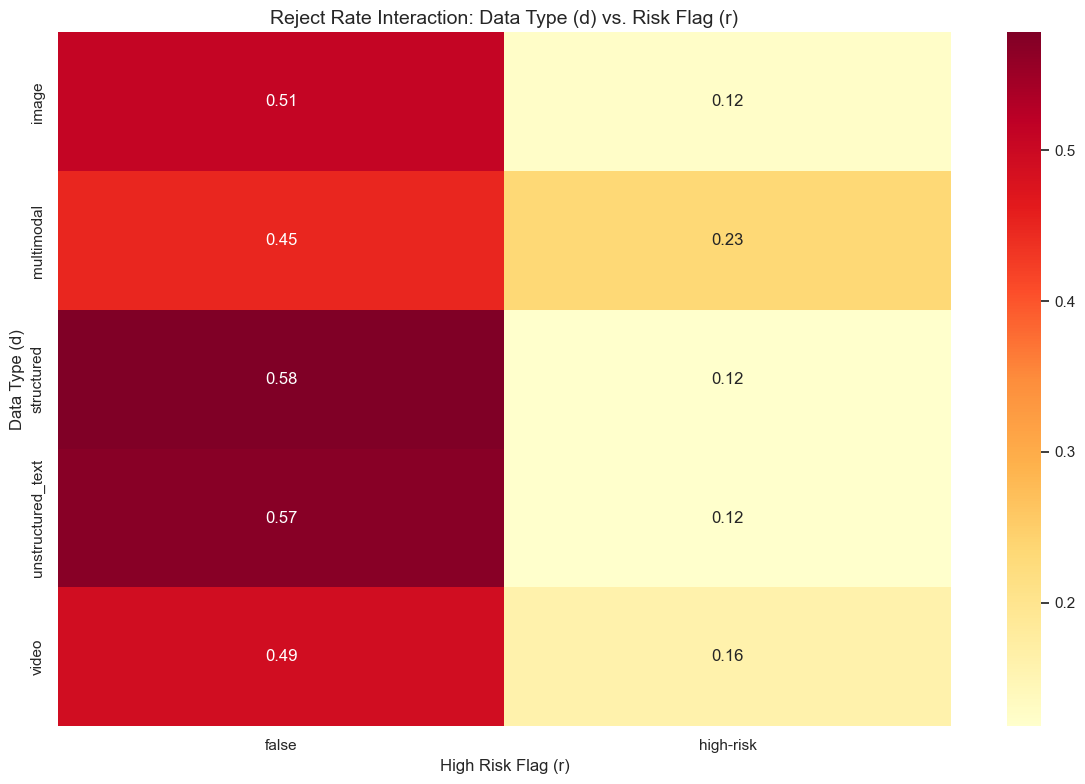

In [17]:
sns.set_theme(style="whitegrid")
plt.rcParams['axes.unicode_minus'] = False
# --- Analysis 1: Multi-Feature Interaction (Reject Rate Matrix) ---
# Observation: Interaction between Data Type (d) and Risk Level (r)
df['final_state'] = df['final_state'].replace({'M1': 'Reject', 'M2': 'Reject', 'M3': 'Reject'})
df['is_reject'] = (df['final_state'] == 'Reject').astype(int)

metrics_list = df['m_metrics'].apply(ast.literal_eval).tolist()
metrics_df = pd.DataFrame(metrics_list, columns=['m_loss', 'm_accuracy', 'm_recall', 'm_precision'])
df = pd.concat([df, metrics_df], axis=1)
plt.figure(figsize=(12, 8))
interaction_pivot = df.pivot_table(index='d', columns='r', values='is_reject', aggfunc='mean')

sns.heatmap(interaction_pivot, annot=True, cmap="YlOrRd", fmt=".2f")
plt.title("Reject Rate Interaction: Data Type (d) vs. Risk Flag (r)", fontsize=14)
plt.ylabel("Data Type (d)")
plt.xlabel("High Risk Flag (r)")
plt.tight_layout()
plt.show()

b值与终端决策之间的关系

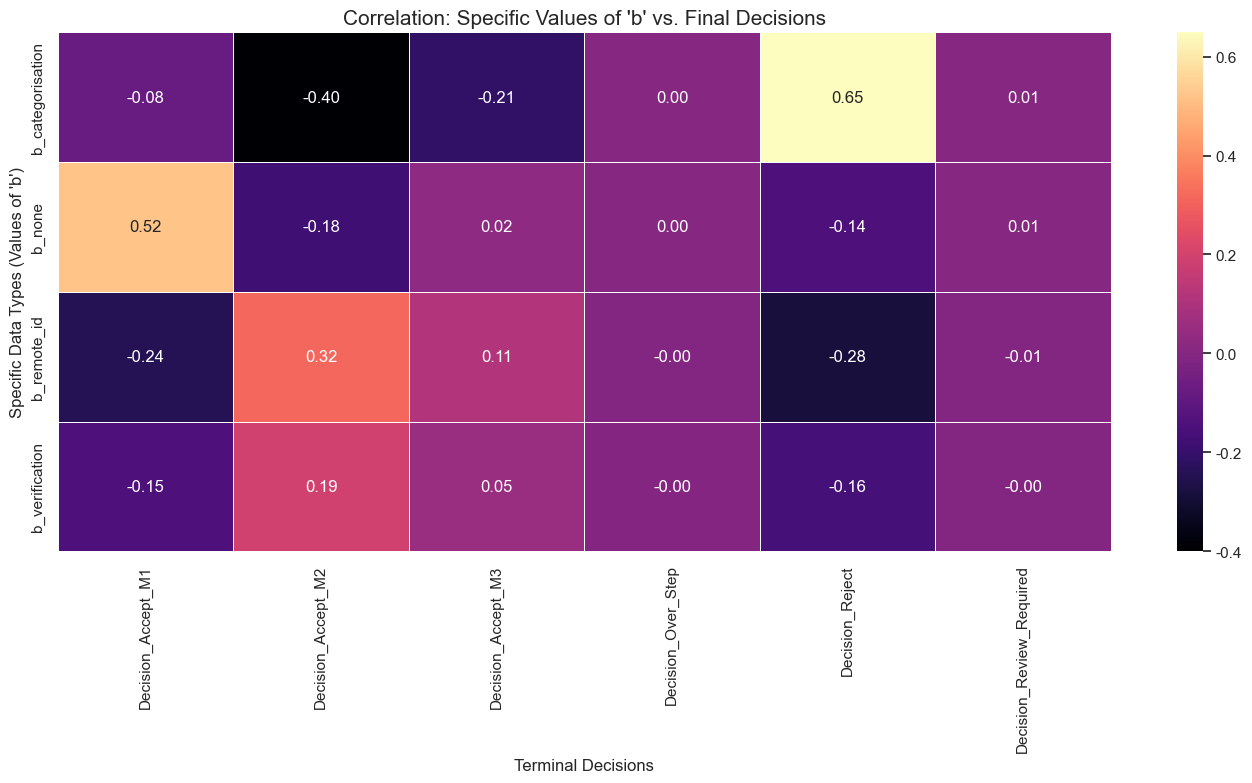

------------------------------
Distribution of Decisions per Data Type (b):
final_state    Accept_M1 Accept_M2 Accept_M3 Over_Step  Reject Review_Required
b                                                                             
categorisation     4.38%      6.6%      0.0%     0.03%  88.98%           0.01%
none               37.9%    28.43%    16.83%     0.03%   16.8%           0.01%
remote_id           0.3%    65.42%    20.15%     0.01%  14.12%            0.0%
verification       0.35%    65.76%    19.04%     0.01%  14.83%            0.0%
------------------------------


In [18]:
sns.set_theme(style="whitegrid")

#将特征 'd' 展开为具体数值列 (One-Hot)
df_d_values = pd.get_dummies(df['b'], prefix='b')
df_decisions = pd.get_dummies(df['final_state'], prefix='Decision')

# 我们只关注 d 的具体值与最终决策之间的关系
df_d_corr = pd.concat([df_d_values, df_decisions], axis=1)
corr_matrix = df_d_corr.corr()
sub_corr = corr_matrix.loc[df_d_values.columns, df_decisions.columns]


plt.figure(figsize=(14, 8))
sns.heatmap(sub_corr, annot=True, cmap="magma", fmt=".2f", linewidths=0.5)

plt.title("Correlation: Specific Values of 'b' vs. Final Decisions", fontsize=15)
plt.xlabel("Terminal Decisions", fontsize=12)
plt.ylabel("Specific Data Types (Values of 'b')", fontsize=12)
plt.tight_layout()
plt.show()
print("-" * 30)
print("Distribution of Decisions per Data Type (b):")
pivot_table = pd.crosstab(df['b'], df['final_state'], normalize='index') * 100
print(pivot_table.round(2).astype(str) + '%')
print("-" * 30)

c值与终端决策之间的关系

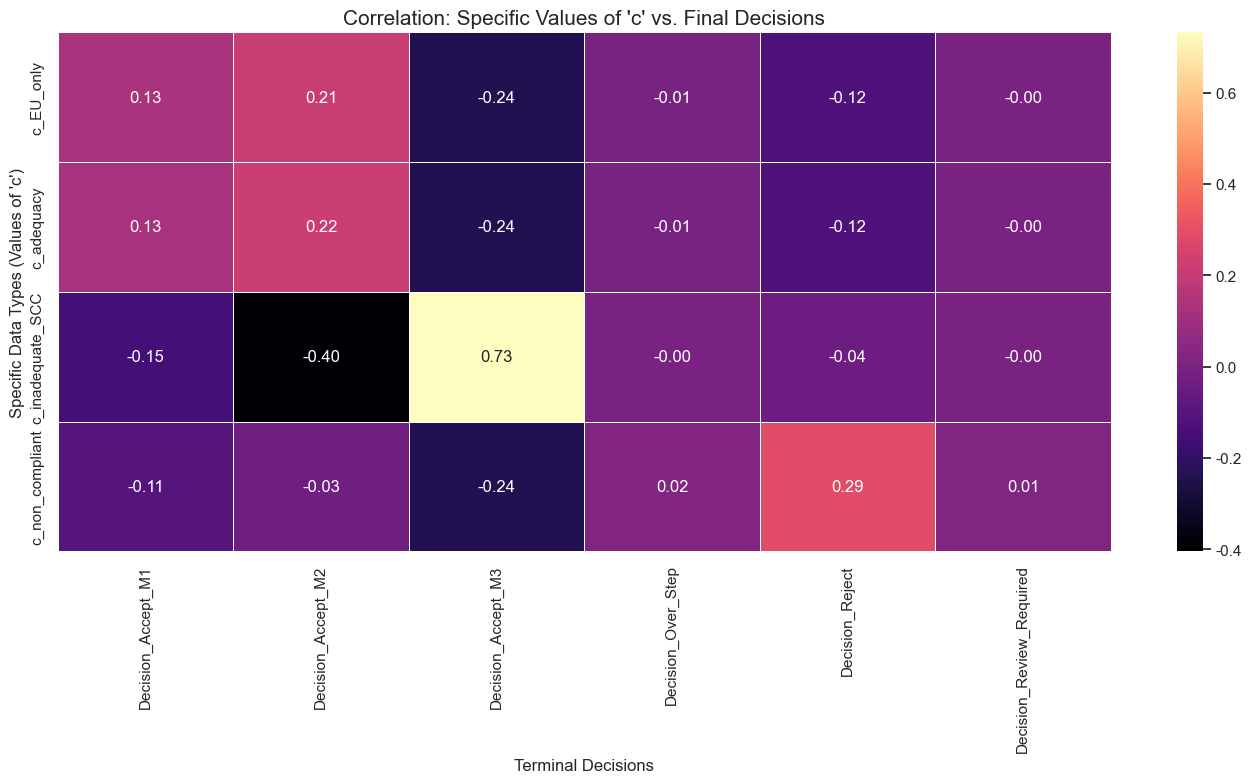

------------------------------
Distribution of Decisions per Data Type (c):
final_state    Accept_M1 Accept_M2 Accept_M3 Over_Step  Reject Review_Required
c                                                                             
EU_only           15.02%    64.72%      0.0%      0.0%  20.27%            0.0%
adequacy          14.82%    65.08%      0.0%      0.0%  20.11%            0.0%
inadequate_SCC     1.17%    11.26%    60.76%     0.01%   26.8%            0.0%
non_compliant      3.48%    43.79%     0.08%     0.07%  52.56%           0.02%
------------------------------


In [19]:
sns.set_theme(style="whitegrid")

#将特征 'd' 展开为具体数值列 (One-Hot)
df_d_values = pd.get_dummies(df['c'], prefix='c')
df_decisions = pd.get_dummies(df['final_state'], prefix='Decision')

# 我们只关注 d 的具体值与最终决策之间的关系
df_d_corr = pd.concat([df_d_values, df_decisions], axis=1)
corr_matrix = df_d_corr.corr()
sub_corr = corr_matrix.loc[df_d_values.columns, df_decisions.columns]


plt.figure(figsize=(14, 8))
sns.heatmap(sub_corr, annot=True, cmap="magma", fmt=".2f", linewidths=0.5)

plt.title("Correlation: Specific Values of 'c' vs. Final Decisions", fontsize=15)
plt.xlabel("Terminal Decisions", fontsize=12)
plt.ylabel("Specific Data Types (Values of 'c')", fontsize=12)
plt.tight_layout()
plt.show()
print("-" * 30)
print("Distribution of Decisions per Data Type (c):")
pivot_table = pd.crosstab(df['c'], df['final_state'], normalize='index') * 100
print(pivot_table.round(2).astype(str) + '%')
print("-" * 30)

执行步数和最终决策以及初始模型的关系

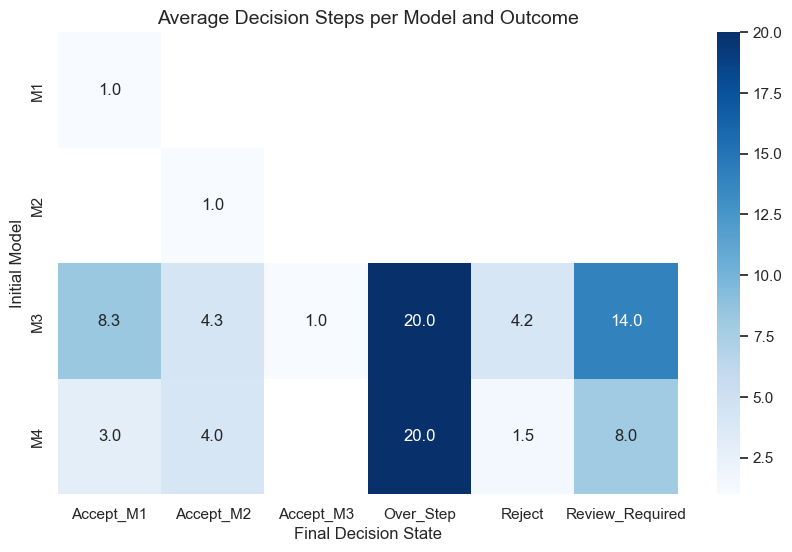

In [20]:
plt.figure(figsize=(10, 6))
step_summary = df.groupby(['initial_identified_model', 'final_state'])['total_steps'].mean().unstack()
sns.heatmap(step_summary, annot=True, cmap="Blues", fmt=".1f")
plt.title("Average Decision Steps per Model and Outcome", fontsize=14)
plt.xlabel("Final Decision State")
plt.ylabel("Initial Model")
plt.show()

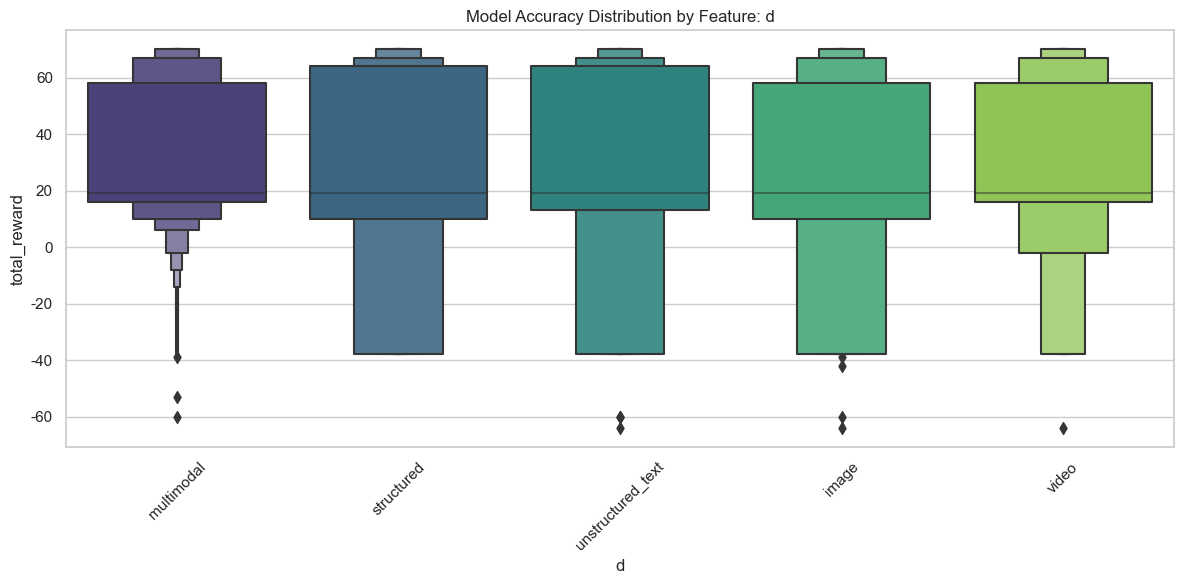

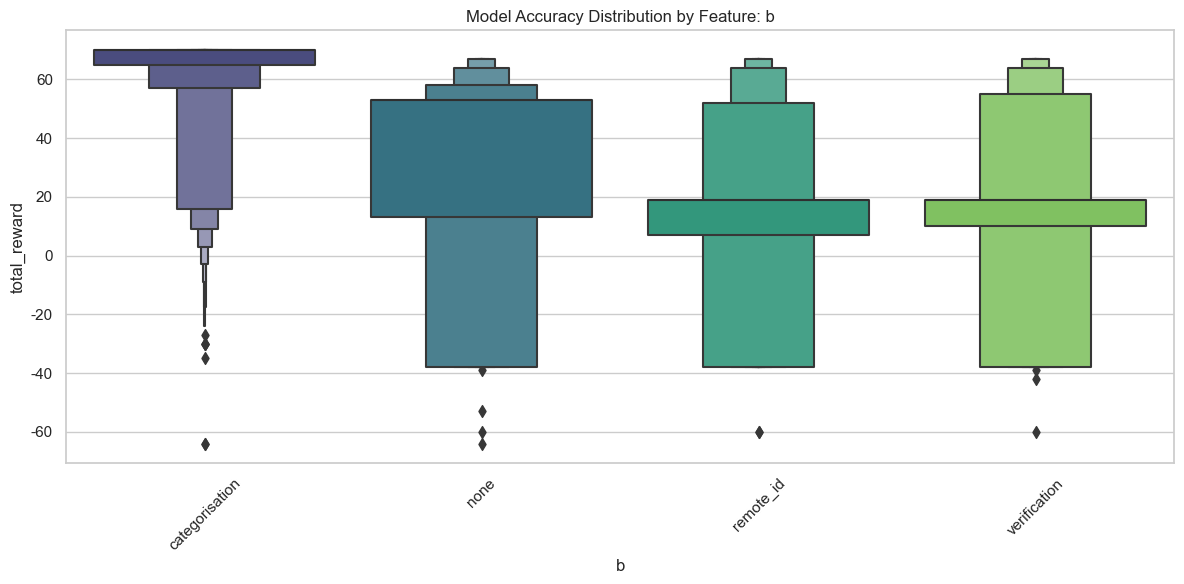

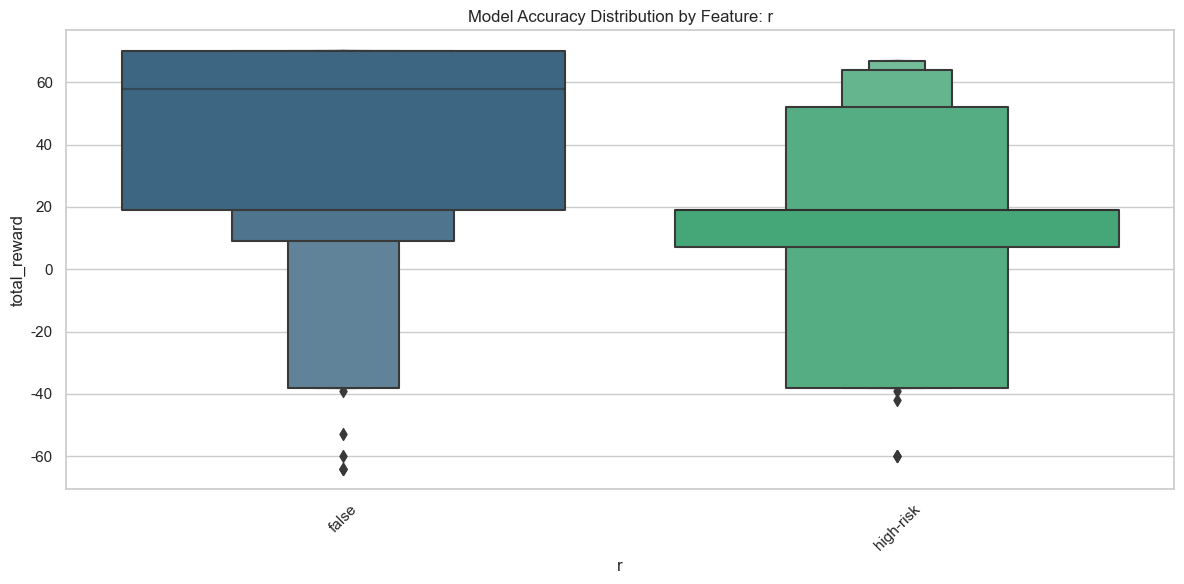

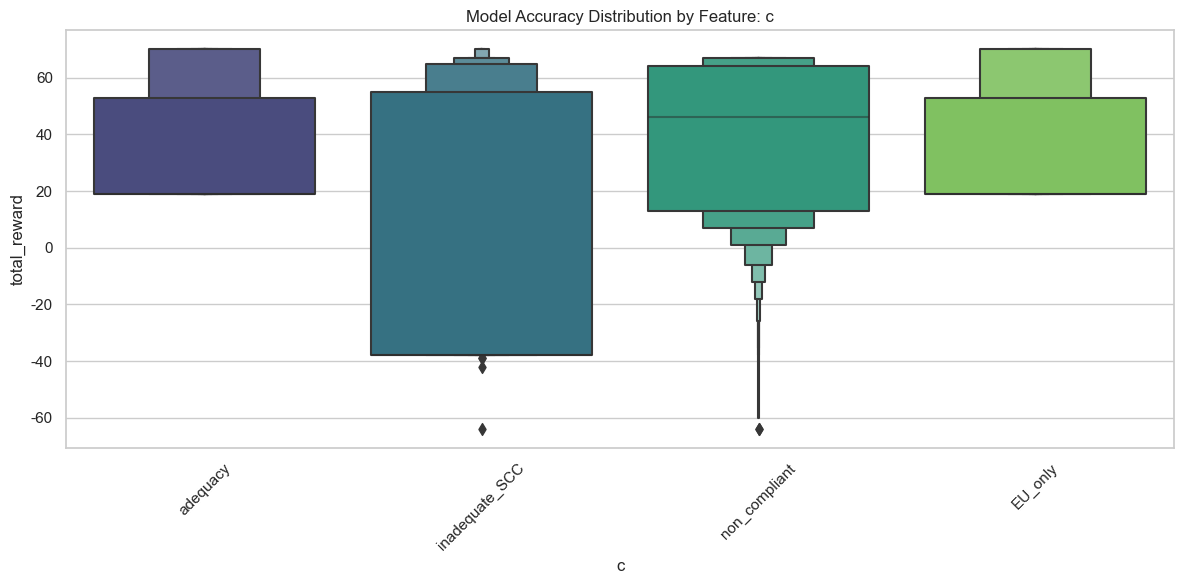

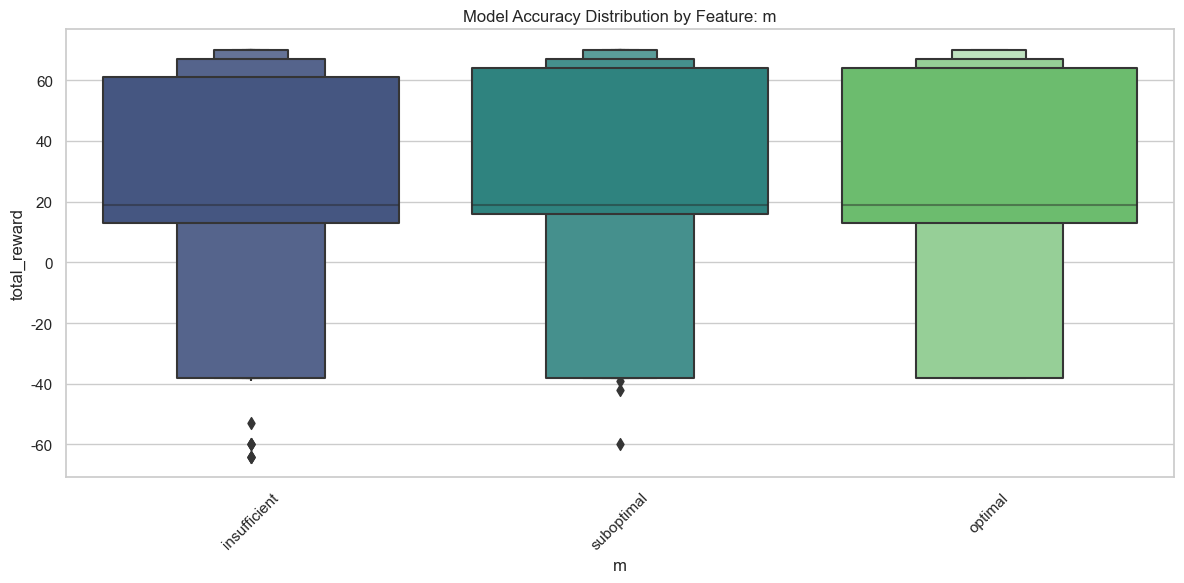

In [21]:
def plot_accuracy_analysis(df, features, label):
    """
    深度分析：针对每一个输入变量，分析其对 m_accuracy 的影响分布
    """
    for col in features:
        plt.figure(figsize=(12, 6))
        # 使用 Boxenplot 适合展示大规模数据的分布，比 Boxplot 更细致
        sns.boxenplot(x=col, y=label, data=df, palette="viridis")
        plt.title(f"Model Accuracy Distribution by Feature: {col}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
label='total_reward'
plot_accuracy_analysis(df, input_features, label)

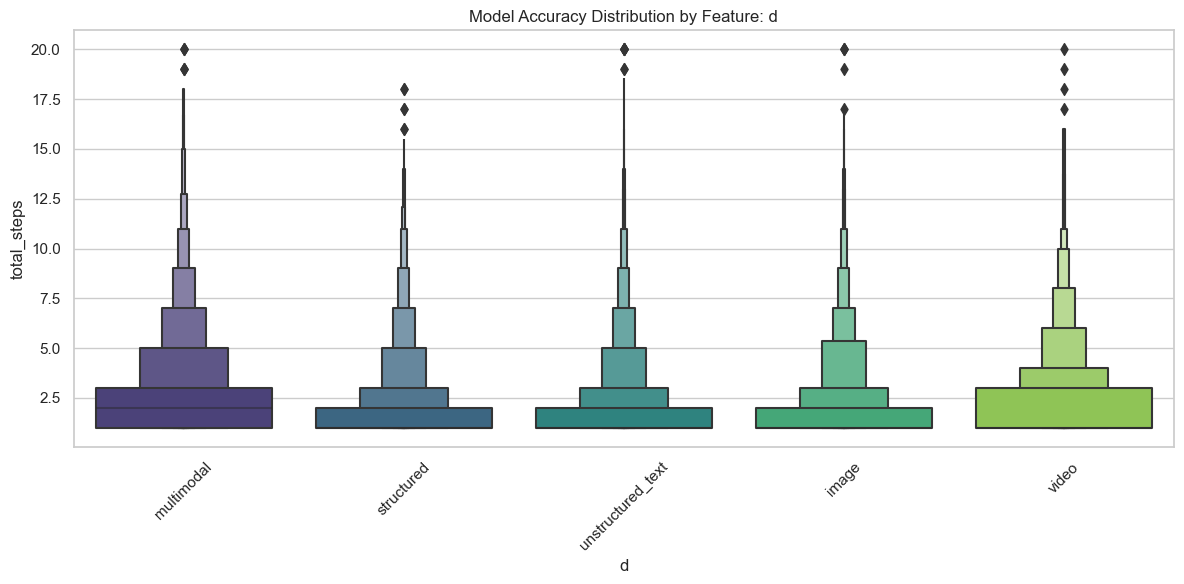

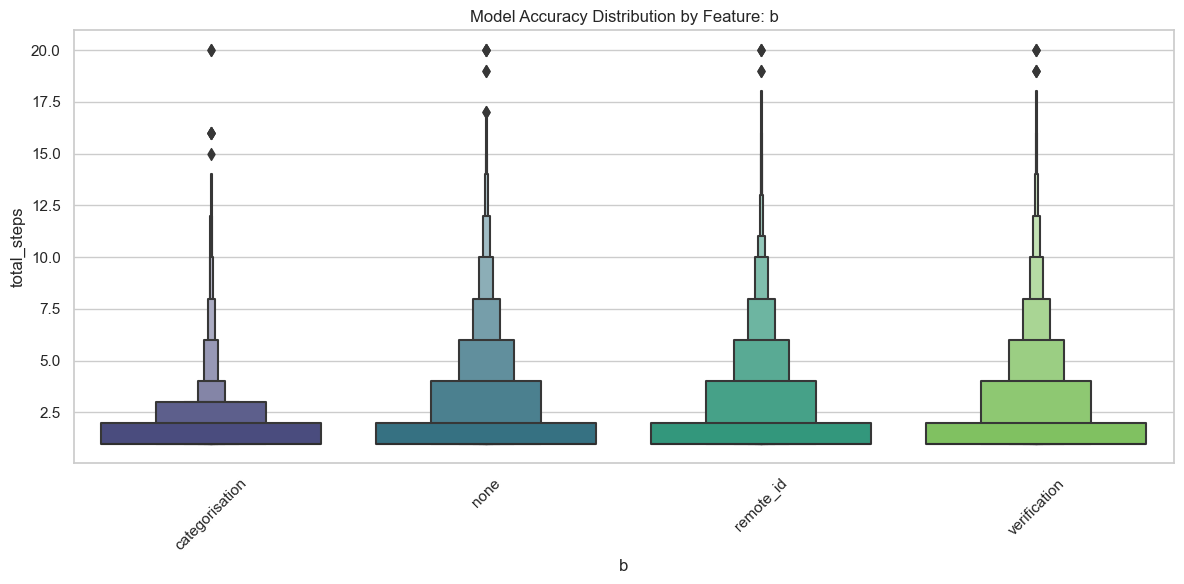

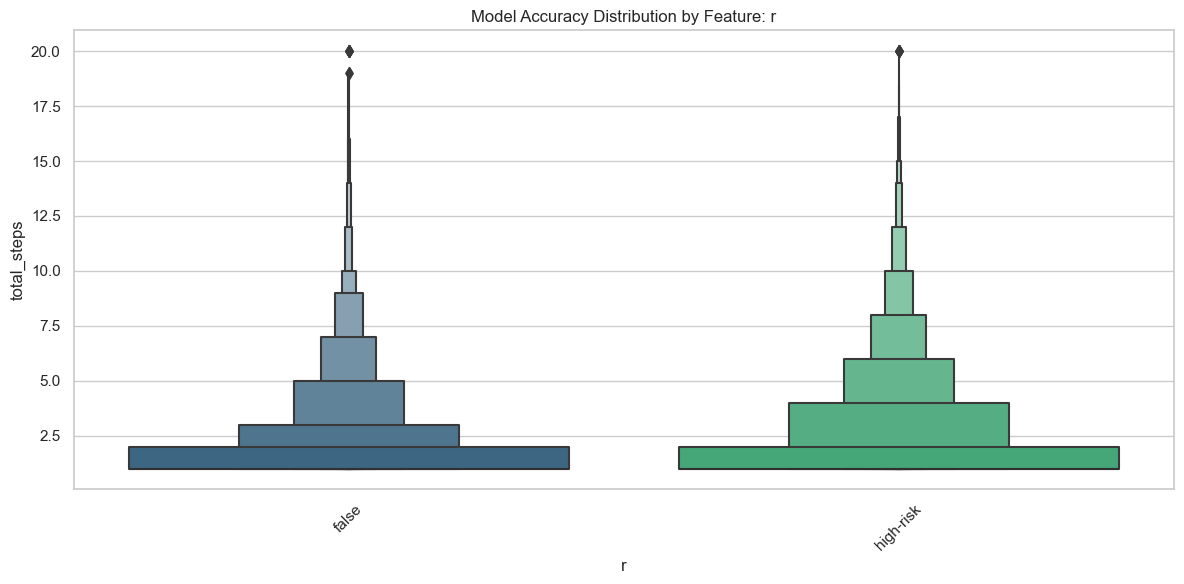

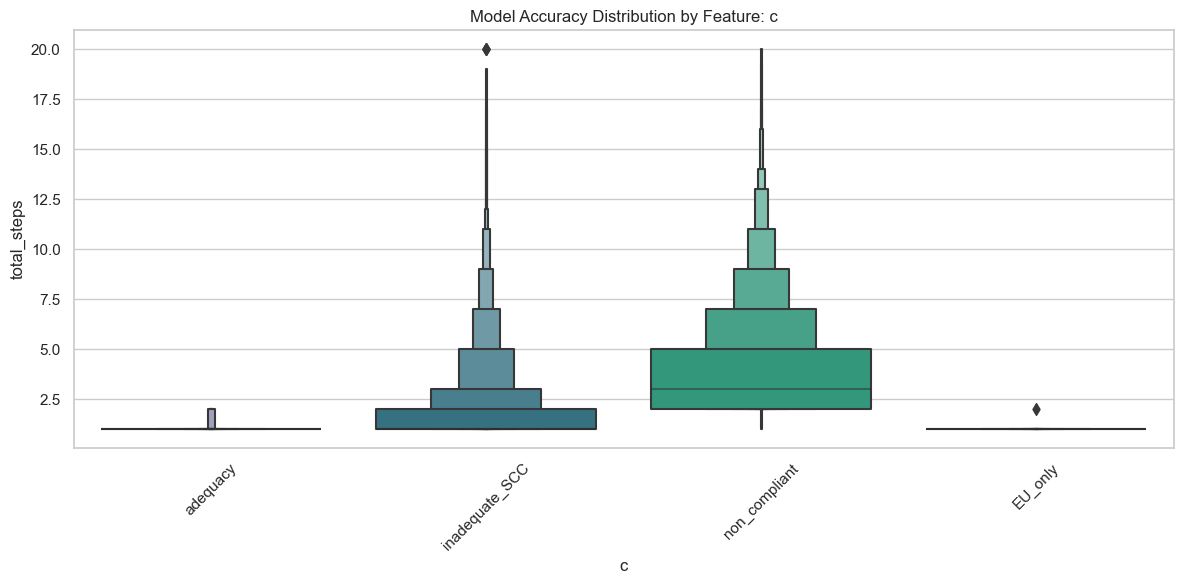

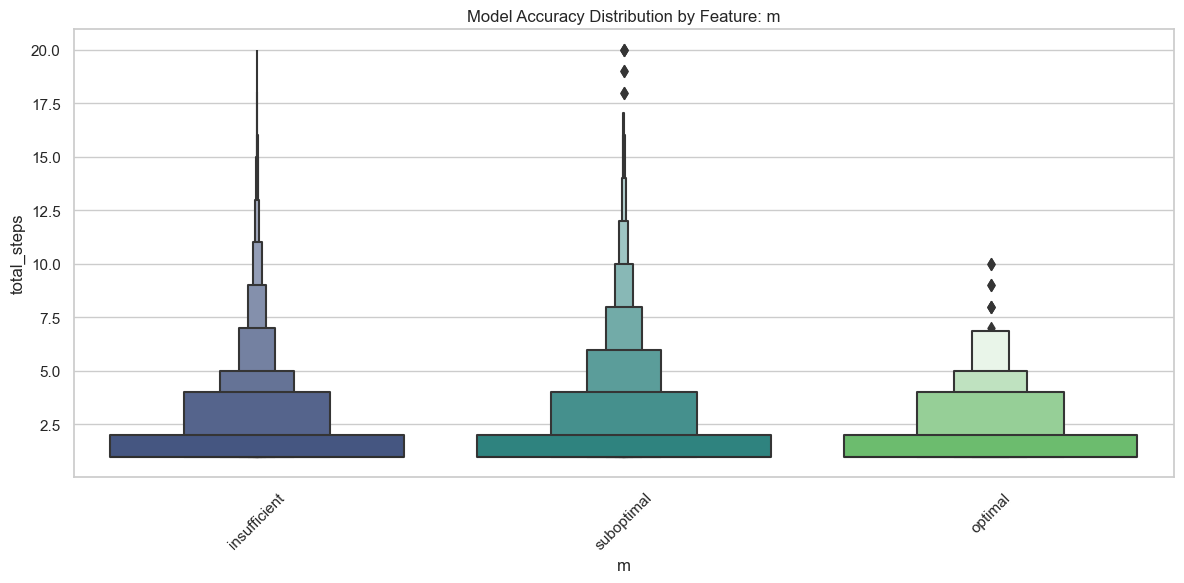

In [22]:
label='total_steps'
plot_accuracy_analysis(df, input_features, label)

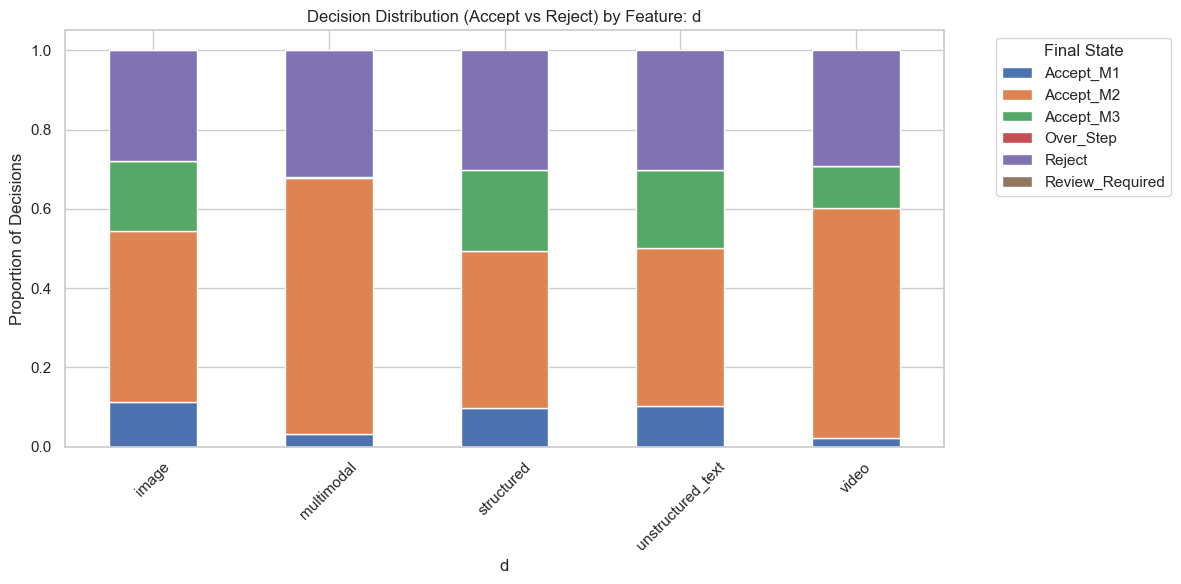

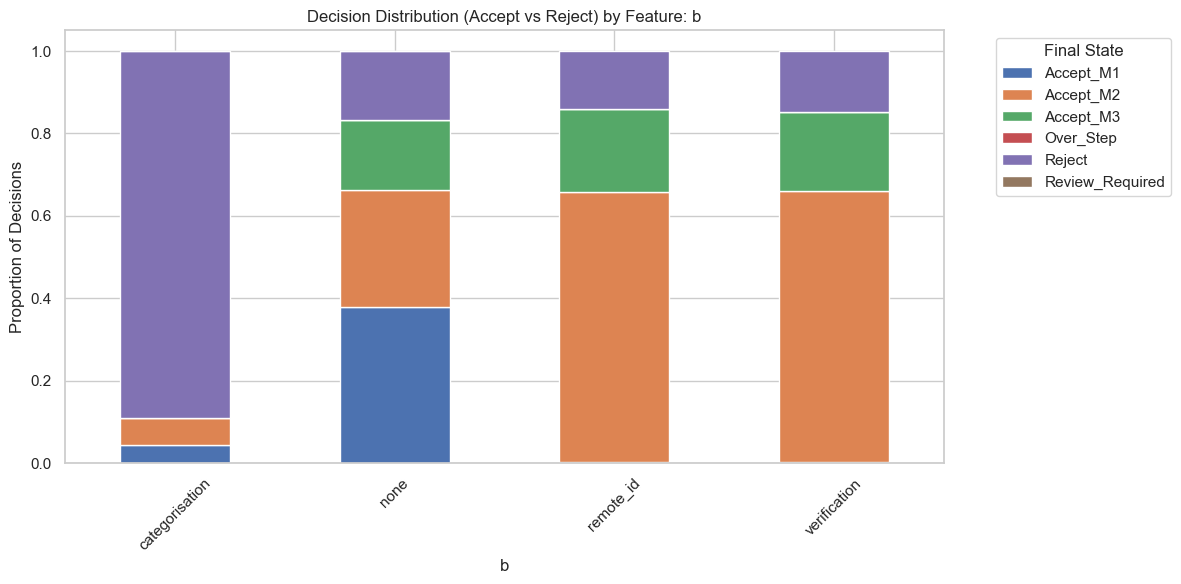

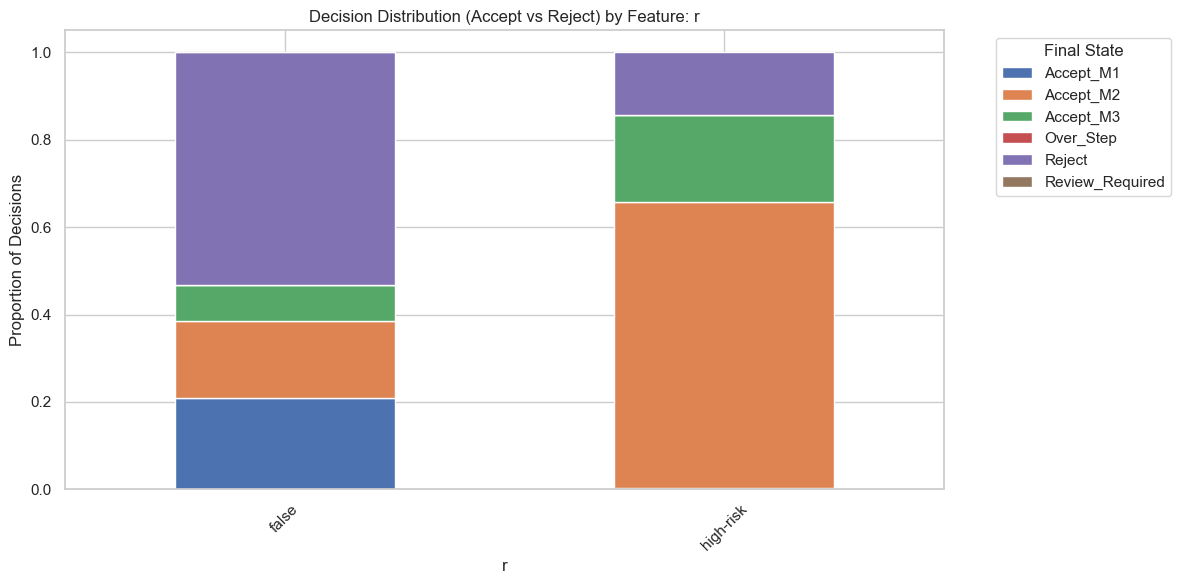

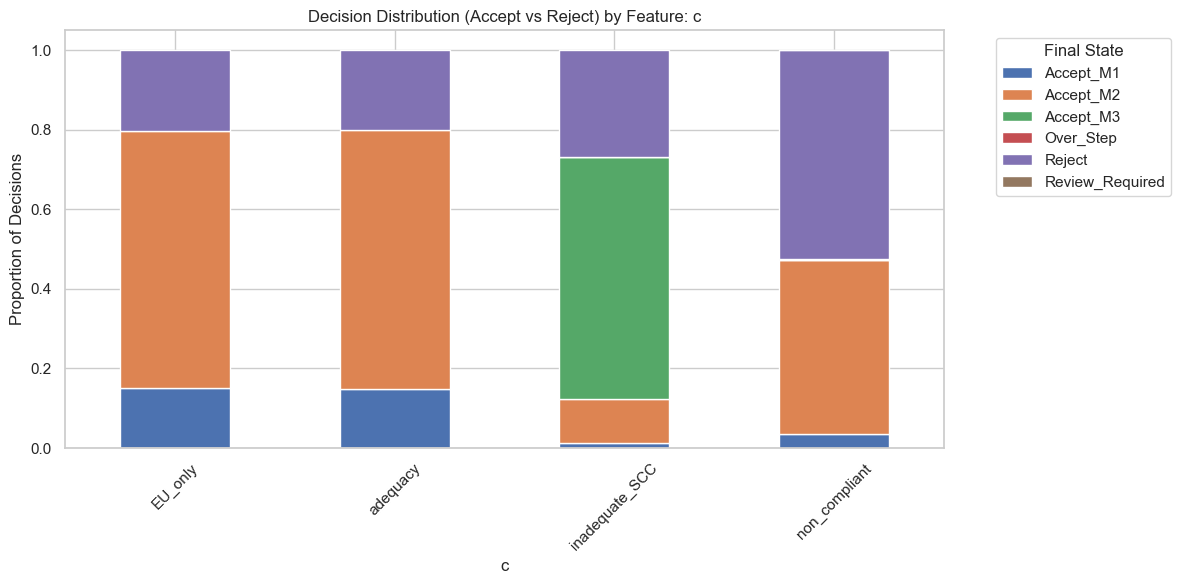

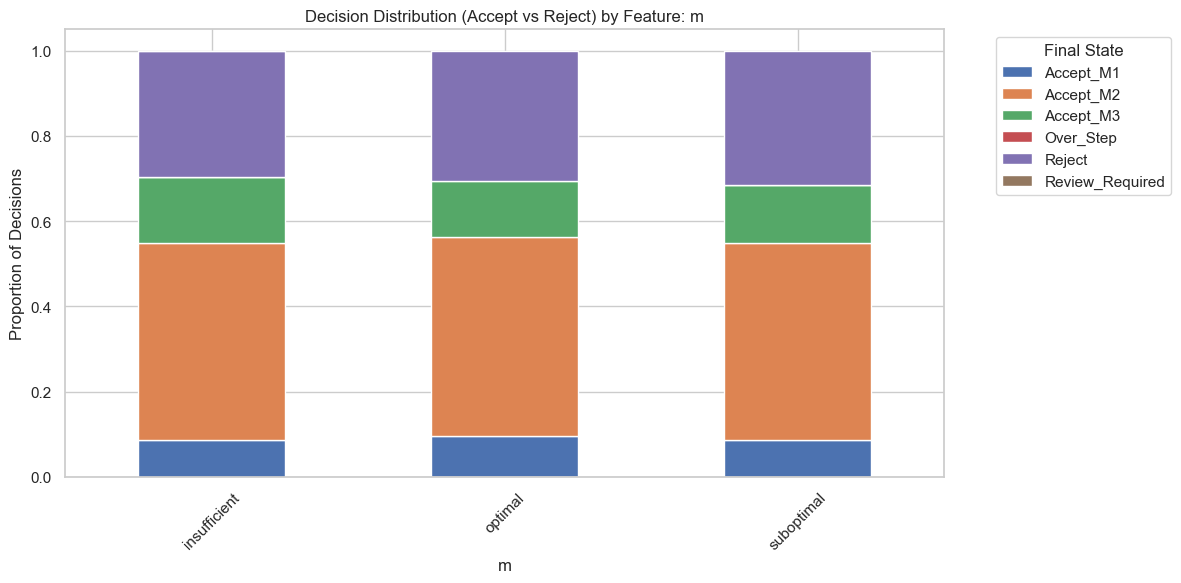

In [23]:
def plot_state_distribution_analysis(df, features, target_col='final_state'):
    """
    修改后：分析不同输入特征对最终决策（Final State）分布的影响
    """
    for col in features:
        plt.figure(figsize=(12, 6))

        # 1. 计算交叉表：特征 vs 状态
        cross_tab = pd.crosstab(df[col], df[target_col])

        # 2. 转换为百分比，以便对比分布比例
        cross_tab_prop = cross_tab.div(cross_tab.sum(1), axis=0)

        # 3. 绘制堆叠柱状图
        cross_tab_prop.plot(kind='bar', stacked=True, ax=plt.gca())

        plt.title(f"Decision Distribution (Accept vs Reject) by Feature: {col}")
        plt.ylabel("Proportion of Decisions")
        plt.xlabel(col)
        plt.legend(title="Final State", bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# 调用函数
plot_state_distribution_analysis(df, input_features)

决策树分析

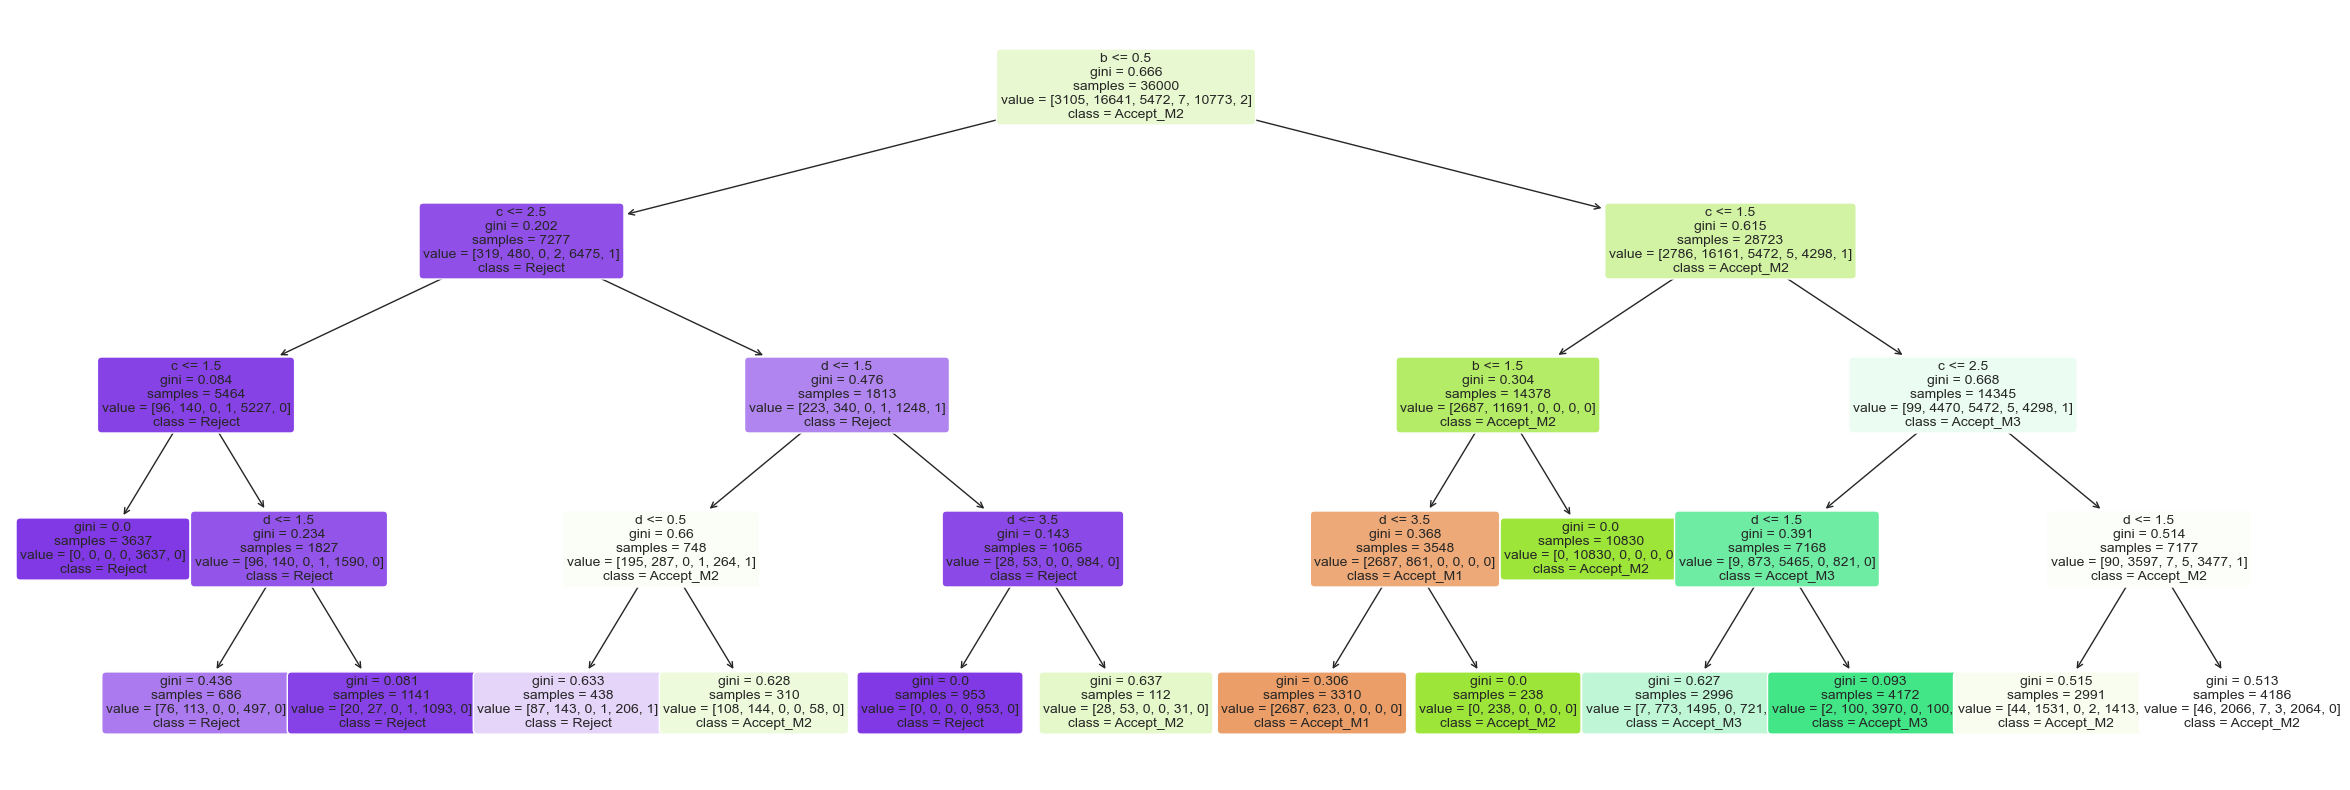

In [24]:
from matplotlib.colors import LinearSegmentedColormap
cmap_colors = ['#FAA26F', '#FEE199', '#B0D6A9']
custom_cmap = LinearSegmentedColormap.from_list("custom_rl", cmap_colors)
le_dict = {}
df_encoded = df_inputs.copy()
for col in input_features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])
    le_dict[col] = le

# 2. 准备目标变量 (final_state)
le_y = LabelEncoder()
y = le_y.fit_transform(df['final_state'])

# 3. 训练决策树
dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=10)
dt.fit(df_encoded, y)

# 4. 可视化决策树
# plt.figure(figsize=(30, 10))
# # 1. 绘图并获取返回的 artist 对象
# artists = plot_tree(dt, feature_names=input_features,
#                     class_names=le_y.classes_,
#                     filled=True, rounded=True, fontsize=10)
#
# # 2. 自定义颜色填充逻辑
# # 我们将两类结局分配给色板的两端：
# # Accept -> 冷色调 (my_palette[0])
# # Reject -> 暖色调 (my_palette[-1])
#
# for artist in artists:
#     # 获取节点的文本内容来判断它属于哪一类
#     node_text = artist.get_text()
#
#     # 根据类别关键字修改颜色 (请确保 class_names 正确)
#     if "class = Accept" in node_text:
#         artist.set_bbox(dict(facecolor='#7BC0CD', edgecolor='black', boxstyle='round,pad=0.3'))
#     elif "class = Reject" in node_text:
#         artist.set_bbox(dict(facecolor='#ED8D5A', edgecolor='black', boxstyle='round,pad=0.3'))
#     else:
#         # 中间决策节点使用中性色
#         artist.set_bbox(dict(facecolor='#DBCB92', edgecolor='grey', boxstyle='round,pad=0.3'))
#
# plt.title("Decision Tree: Customized Color Scheme (Input Features vs Final State)", fontsize=15)
# plt.show()
plt.figure(figsize=(30, 10))
# plot_tree 本身不支持直接传 cmap，但我们可以修改生成的 patch
viz = plot_tree(dt, feature_names=input_features, class_names=le_y.classes_,
                filled=True, rounded=True, fontsize=10)

for artist in viz:
    # 获取节点的 Gini 指数或 Value 来决定颜色深浅
    # 这里通过 artist 关联的矩形框修改颜色
    if isinstance(artist, plt.Text):
        # 这里的逻辑可以根据你的具体类别索引进一步微调
        pass

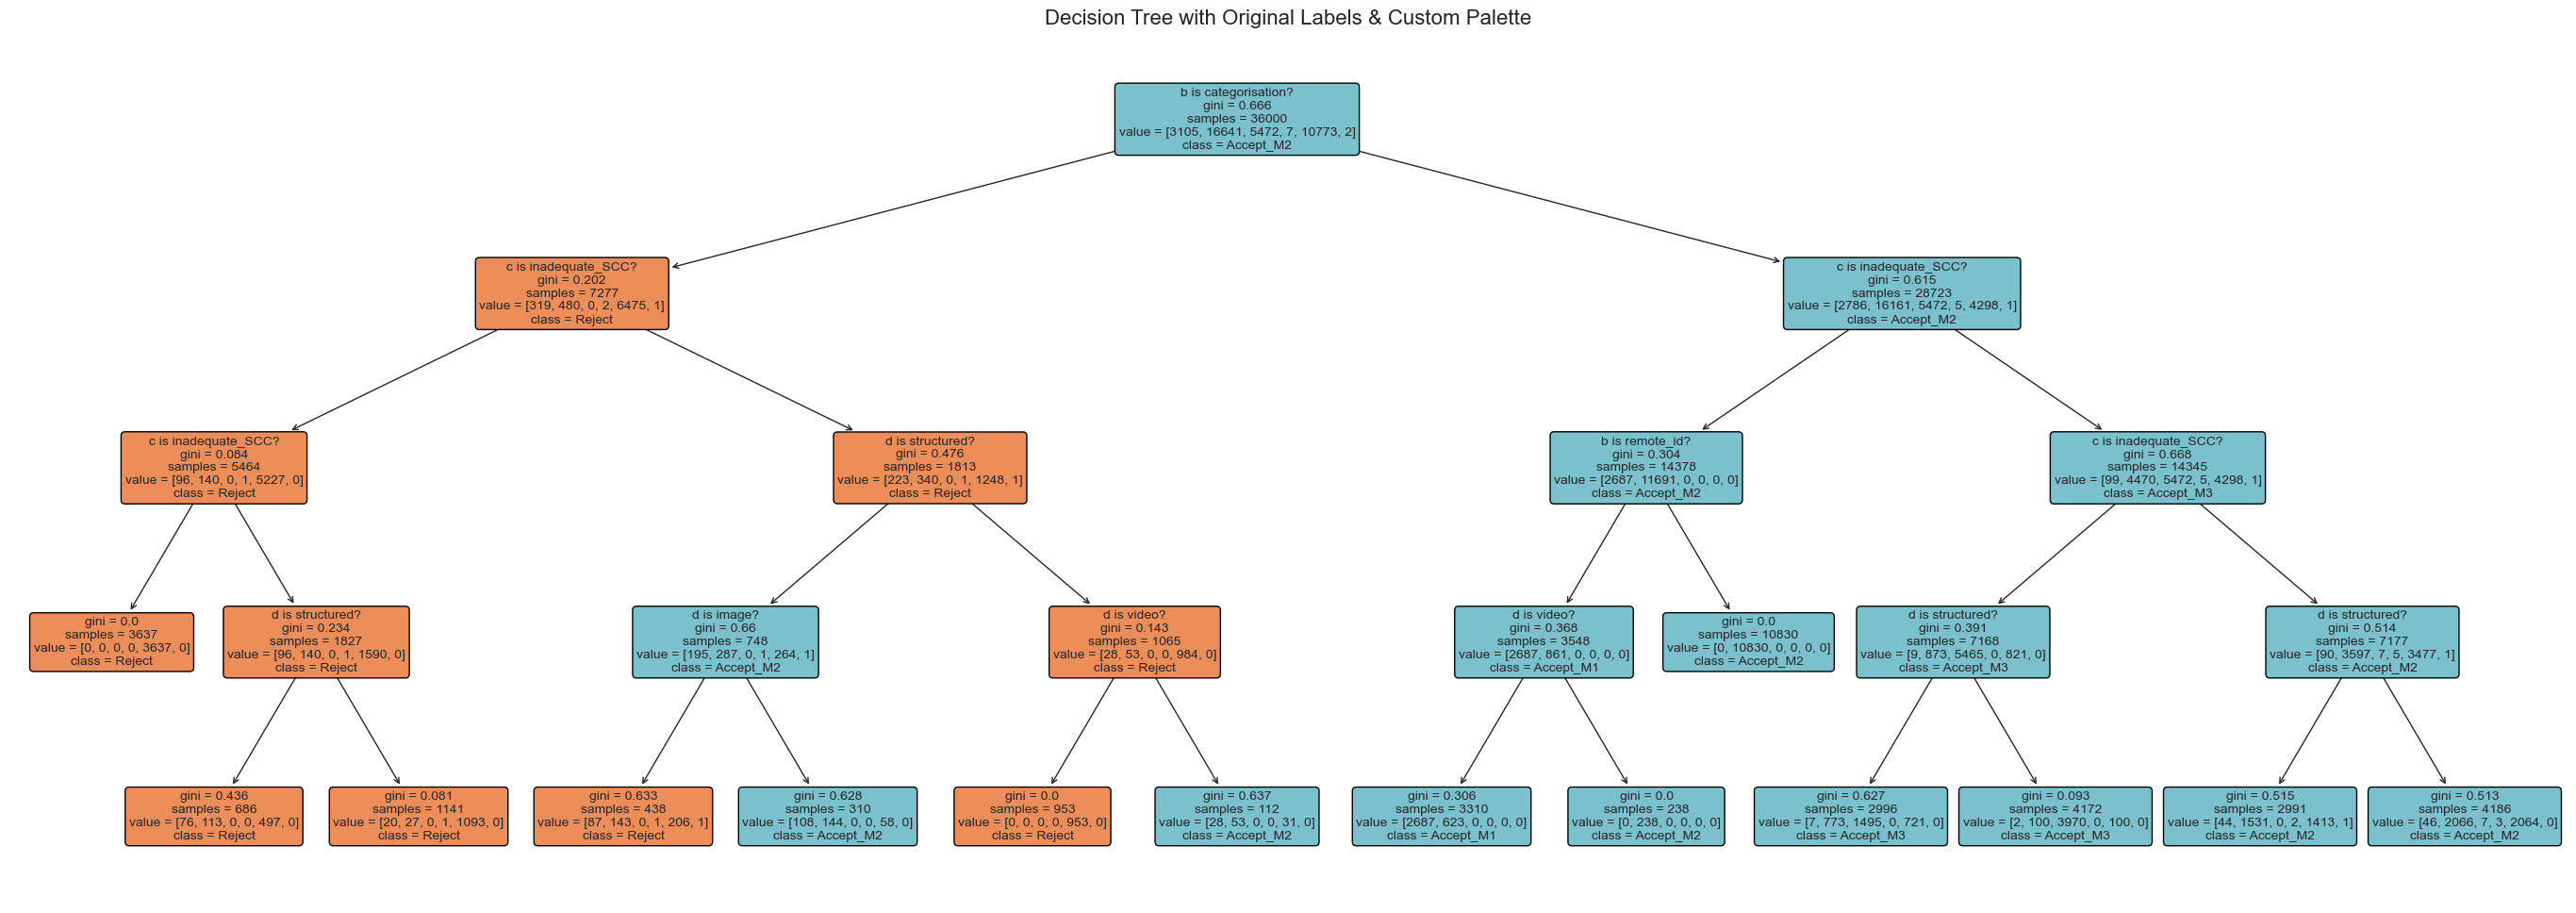

In [25]:
import re
plt.figure(figsize=(35, 12))
# 1. 正常绘图并获取返回的 artists
artists = plot_tree(dt, feature_names=input_features,
                    class_names=le_y.classes_,
                    filled=True, rounded=True, fontsize=10)

# 2. 遍历每个节点，替换编码值为原始标签
for artist in artists:
    text = artist.get_text()

    # 使用正则表达式匹配类似 "d <= 0.5" 或 "c <= 1.5" 的模式
    for col in input_features:
        pattern = rf"{col} <= ([\d\.]+)"
        match = re.search(pattern, text)

        if match:
            threshold = float(match.group(1))
            # 找到最接近该阈值的原始标签
            # 因为 LabelEncoder 是按字母排序分配 0, 1, 2...
            # <= 0.5 通常意味着索引为 0 的那个类别
            original_labels = le_dict[col].classes_
            idx = int(round(threshold))

            # 这里的逻辑：<= 0.5 指的是判断是否为第一个类别
            if idx < len(original_labels):
                label_val = original_labels[idx]
                new_text = text.replace(f"{col} <= {match.group(1)}", f"{col} is {label_val}?")
                artist.set_text(new_text)

    if "class = Accept" in text:
        artist.set_bbox(dict(facecolor='#7BC0CD', edgecolor='black', boxstyle='round,pad=0.3'))
    elif "class = Reject" in text:
        artist.set_bbox(dict(facecolor='#ED8D5A', edgecolor='black', boxstyle='round,pad=0.3'))
    else:
        artist.set_bbox(dict(facecolor='#DBCB92', edgecolor='grey', boxstyle='round,pad=0.3'))

plt.title("Decision Tree with Original Labels & Custom Palette", fontsize=16)
plt.show()

决策路径分析

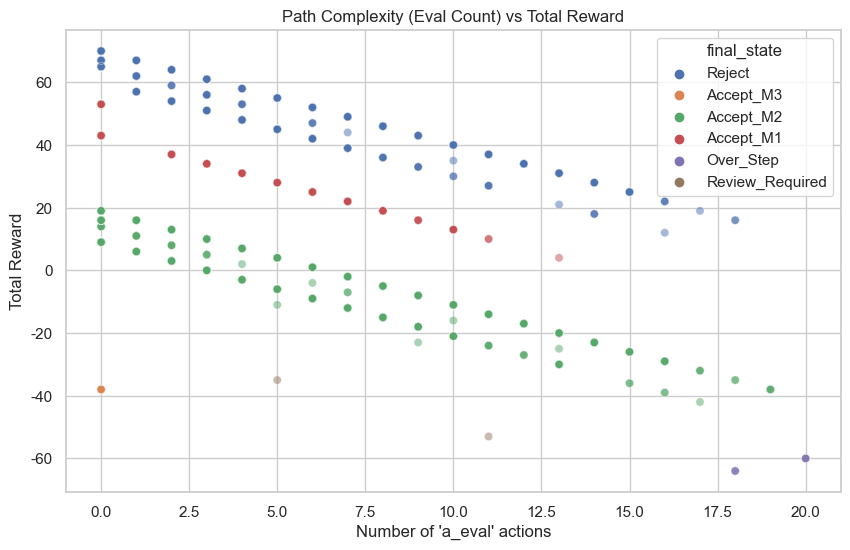

Decision Path Statistics by Final State:
                 total_steps            total_reward
                       mean median max         mean
final_state                                        
Accept_M1          1.438003    1.0  16    51.147504
Accept_M2          1.983114    1.0  20    15.911123
Accept_M3          1.000000    1.0   1   -38.000000
Over_Step         20.000000   20.0  20   -61.714286
Reject             2.578298    2.0  19    64.859278
Review_Required   11.000000   11.0  14   -44.000000


In [26]:
# 1. 提取路径复杂度：计算 a_eval 的次数
df['eval_count'] = df['actions_sequence'].str.count('a_eval')

# 2. 分析路径长度与奖励的关系
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='eval_count', y='total_reward', hue='final_state', alpha=0.5)
plt.title("Path Complexity (Eval Count) vs Total Reward")
plt.xlabel("Number of 'a_eval' actions")
plt.ylabel("Total Reward")
plt.show()

# 3. 统计不同结局的平均步数
path_stats = df.groupby('final_state').agg({
    'total_steps': ['mean', 'median', 'max'],
    'total_reward': 'mean'
})
print("Decision Path Statistics by Final State:\n", path_stats)

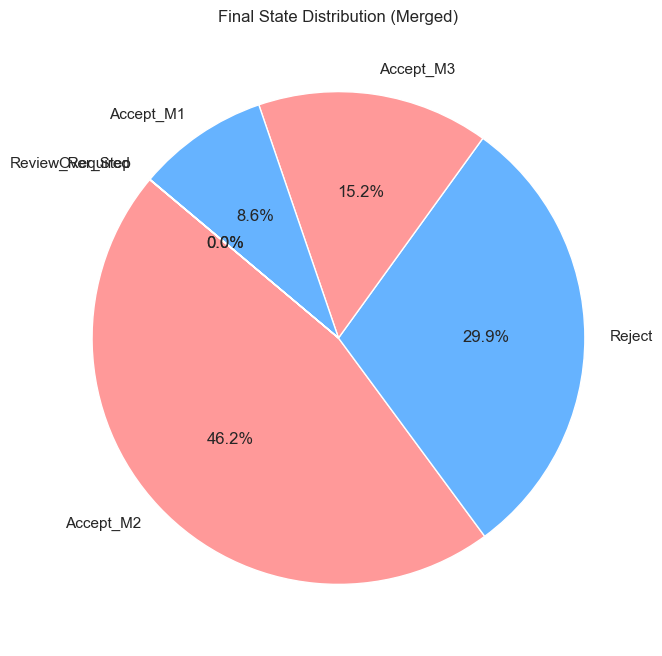

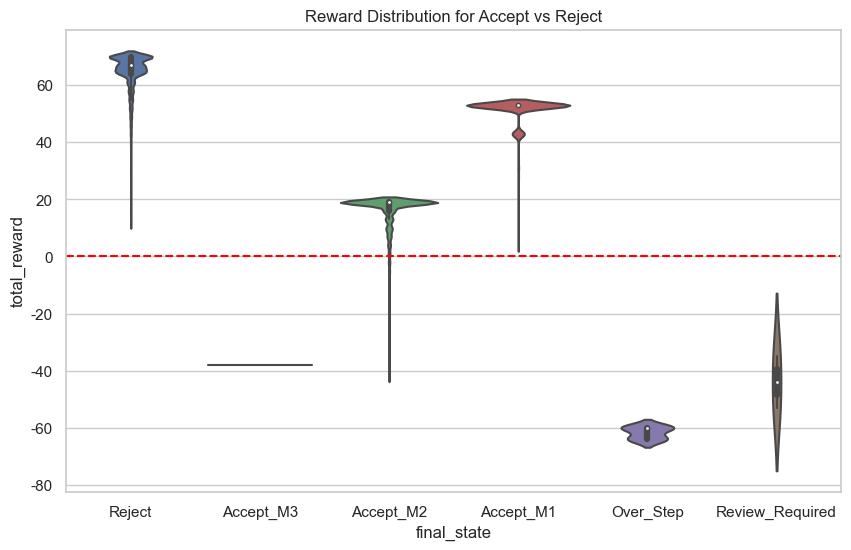

In [27]:
# 状态占比饼图
state_counts = df['final_state'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(state_counts, labels=state_counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
plt.title("Final State Distribution (Merged)")
plt.show()

# 奖励密度分析 (Violin Plot)
plt.figure(figsize=(10, 6))
sns.violinplot(x='final_state', y='total_reward', data=df)
plt.title("Reward Distribution for Accept vs Reject")
plt.axhline(0, color='red', linestyle='--') # 检查有多少决策是在 0 分以下的
plt.show()

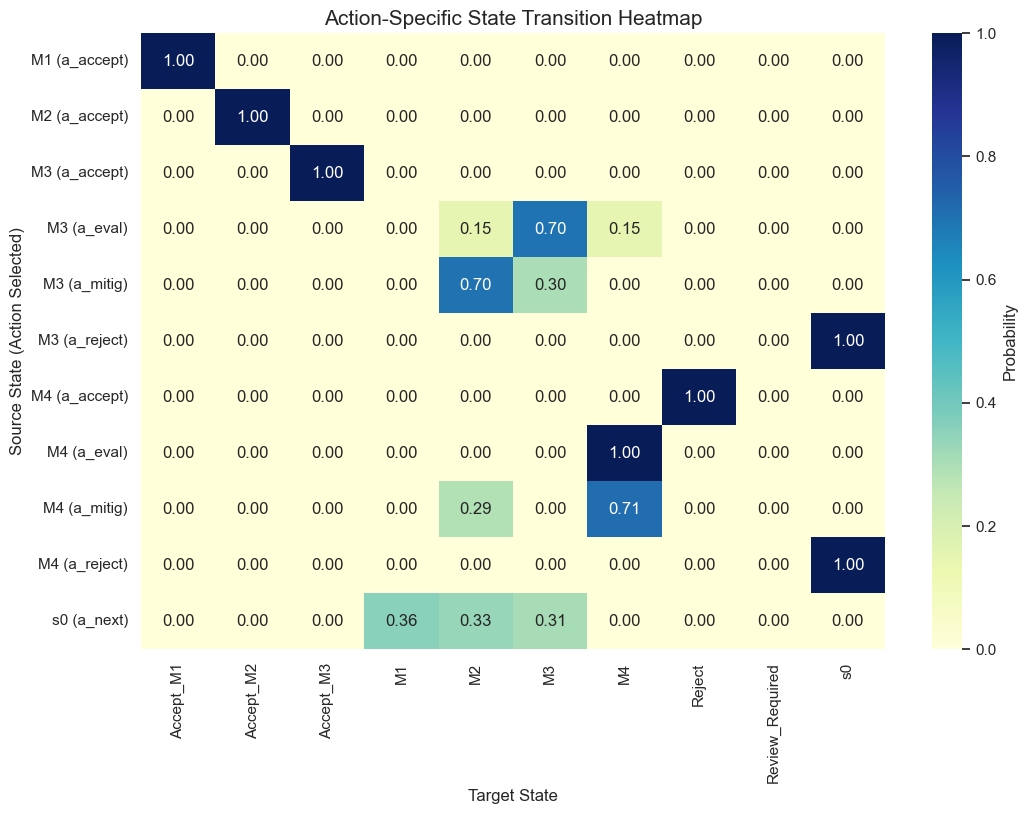

In [28]:
df = pd.read_csv("transition_probabilities.csv")
pivot_df = df.pivot(index=['current_state', 'action'], columns='next_state', values='probability').fillna(0)

def plot_transition_heatmap(df):
    # 创建组合标签
    df['state_action'] = df['current_state'] + " (" + df['action'] + ")"
    pivot_df = df.pivot(index='state_action', columns='next_state', values='probability').fillna(0)

    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot_df, annot=True, cmap="YlGnBu", fmt=".2f", cbar_kws={'label': 'Probability'})
    plt.title("Action-Specific State Transition Heatmap", fontsize=15)
    plt.ylabel("Source State (Action Selected)")
    plt.xlabel("Target State")
    plt.show()

plot_transition_heatmap(df)

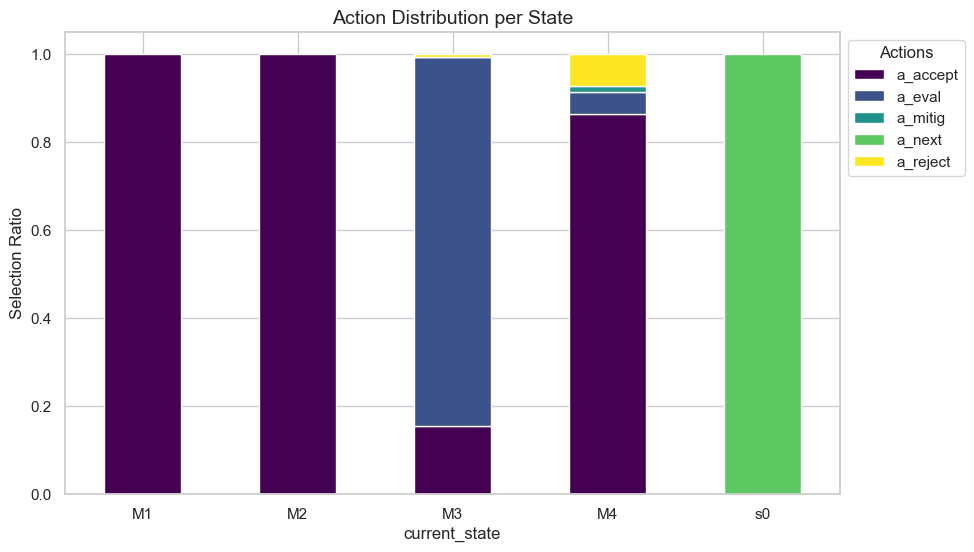

In [29]:
def plot_action_preference(df):
    # 计算每个状态下各动作的总次数
    action_counts = df.groupby(['current_state', 'action'])['count'].sum().unstack().fillna(0)
    # 归一化为百分比
    action_pct = action_counts.div(action_counts.sum(axis=1), axis=0)

    action_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap="viridis")
    plt.title("Action Distribution per State", fontsize=14)
    plt.ylabel("Selection Ratio")
    plt.legend(title="Actions", bbox_to_anchor=(1, 1))
    plt.xticks(rotation=0)
    plt.show()

plot_action_preference(df)

判断a_eval动作是否有用

KeyError: "None of [Index(['d', 'b', 'r', 'c', 'm'], dtype='object')] are in the [columns]"